[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/)

# 투빅스 25&26기 2주차 2교시 — Deep Learning 과제 [sklearn `digits` 손글씨 분류]


## 과제 목적

이번 과제는 `sklearn`의 `digits` 데이터셋을 이용해 **MLP를 직접 학습**하고, DNN의 세 가지 고질병인 **Vanishing Gradient · Overfitting · Optimization**을 실제 실험 결과로 확인하는 프로젝트입니다. §1.1에서는 데이터를 확인하고 train / validation / test로 분리하며, §1.2에서는 PyTorch로 미니배치 SGD 학습 루프를 완성합니다. 이어지는 §1.3~1.5에서는 활성화 함수, 규제 방법, optimizer를 하나씩 바꾸며 강의의 설명이 실제 학습 곡선과 수치에서 어떻게 나타나는지 검증합니다. 마지막 심화(§2)에서는 "활성화 함수가 없으면 층을 쌓아도 선형모델"이라는 주장을 직접 확인하고, 파라미터 수를 맞춘 Wide vs Deep 비교를 통해 "Deep이 항상 더 좋은가"를 본인 실험으로 판단합니다.

## 주의 사항
각 코드 셀의 빈칸(`# TODO: ____`, `____`)을 채우며 **"지금 어느 단계에서 무엇을 하고 있는가"**를 확인하세요. 앞 단계에서 만든 변수와 함수가 뒤 절에서 계속 사용되므로 **맨 위 셀부터 순서대로** 실행해야 합니다.


## 제출물

1. 빈칸을 모두 채우고 **전부 실행한** 이 노트북 (출력 포함)
2. 기술블로그 '과제 복습' 섹션 — §1.3~1.5의 실험 결과 그래프와 본인 해석을 옮겨 정리


---

## 0. 환경 설정 — 라이브러리, 시드, 데이터 로드

이번 과제는 **별도 파일 업로드가 필요 없습니다.** scikit-learn에 내장된 **`load_digits()`** 를 씁니다.

- **무슨 데이터?** 손글씨 숫자 이미지 **1,797장**. 각 이미지는 **8×8 = 64 픽셀**, 픽셀 값은 **0~16**의 정수(밝기). 정답은 **0~9의 10개 클래스**입니다.
- **왜 이 데이터?** 강의의 마지막 슬라이드 구조(`Input → Hidden → Output`, `# of nodes: 변수 개수(d) / 자유 / Task에 의존`)를 그대로 적용할 수 있습니다. 입력 노드는 **64개(픽셀 수 = d)**, 출력 노드는 **10개(클래스 수 = Task에 의존)**, 은닉층은 **자유**입니다. 그리고 크기가 작아 Colab CPU에서도 실험 하나가 몇 초면 끝나므로, **여러 조건을 비교**하는 이번 과제에 적합합니다.

이 셀에서 하는 일은 세 가지입니다.

**1) 라이브러리 import.** 이후 모든 셀이 여기서 불러온 이름(`np`, `torch`, `nn` 등)을 씁니다. 한 번만 실행하면 됩니다.

**2) `MY_SEED` 설정.** *시드(seed)* 는 난수 생성기의 출발점입니다. 딥러닝에는 무작위가 **최소 세 군데** 들어갑니다 — ① **가중치 초기화**, ② **train/val/test 분할**, ③ **미니배치 셔플 순서**. 시드를 고정해야 재현이 되고 채점이 가능합니다.

**3) 데이터 로드.** `load_digits()`는 sklearn 패키지 안에 들어 있어 인터넷 없이도 즉시 로드됩니다.

> 시드를 고정한다고 결과가 **편향**되는 것은 아닙니다. 무작위 절차를 **재현 가능**하게 만들 뿐입니다.

In [21]:
# ── 라이브러리 import (한 번만 실행; 이후 모든 셀이 이 이름을 그대로 사용) ──
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ── 0. 환경 설정 ──────────────────────────────────────────────
# (1) 시드 설정 — 본인 학번 뒷 4자리를 넣으세요 (예: 2026-12345 → 2345)
MY_SEED = 8664              # TODO: 학번 뒷 4자리 (학번이 0829라서 0으로 시작함, 핸드폰 뒷번호로 시작)
np.random.seed(MY_SEED)        # TODO: NumPy 난수 고정
torch.manual_seed(MY_SEED)     # TODO: PyTorch 난수 고정 (가중치 초기화·셔플에 영향)

# (2) 데이터 로드 — sklearn 내장 데이터라 다운로드/업로드가 필요 없다
digits = load_digits()
X = digits.data          # (n_samples, 64)  픽셀 밝기 0~16
y = digits.target        # (n_samples,)     정답 클래스 0~9

# (3) 로드 확인
print("PyTorch version :", torch.__version__)
print("MY_SEED         :", MY_SEED)
print("X shape (샘플수, 픽셀수) :", X.shape)      # 기대: (1797, 64)
print("y shape                  :", y.shape)
print("클래스 종류              :", np.unique(y))
print("픽셀 값 범위             :", X.min(), "~", X.max())

PyTorch version : 2.11.0+cpu
MY_SEED         : 8664
X shape (샘플수, 픽셀수) : (1797, 64)
y shape                  : (1797,)
클래스 종류              : [0 1 2 3 4 5 6 7 8 9]
픽셀 값 범위             : 0.0 ~ 16.0


**Q0. 데이터를 제대로 불렀는지 확인해 봅시다.**

1. `X.shape`는 무엇인가요? **샘플 수**와 **픽셀 수**를 본인이 본 실제 숫자로 적으세요. `X.shape는 (1797, 64)이고, 전체 샘플수는 1797개고 각 샘플을 나타내는 픽셀 수는 64개이다.`
2. 강의 마지막 NN Structure 표(p.28)에 따르면 **Input layer의 노드 수 = 변수 개수(d)**, **Output layer의 노드 수 = Task에 의존**입니다. 이 데이터에서 입력 노드 수와 출력 노드 수는 각각 몇 개여야 하나요? 그 근거를 위 출력값으로 대세요. `Input layer의 노드 수는 변수 개수와 같기 때문에 64개이다. Output layer의 노드 수는 숫자 0부터 9까지 총 10개의 클래스를 분류하므로 10개이다.`
3. `MY_SEED`를 다른 값으로 바꿔 이 셀을 다시 실행하면 `X.shape`가 달라질까요? 한 줄로 설명하세요. `MY_SEED를 다른 값으로 변경해도 X.shape은 (1797, 64)로 같다. 난수 시드는 모델의 가중치 초기화나 데이터 분할처럼 무작위성이 포함된 과정에는 영향을 주지만, 저장된 데이터를 불러오는 과정과 원래 데이터의 크기에는 영향을 주지 않기 때문이다.`

> 힌트(3번): 시드는 *무작위 절차*(초기화·셔플·분할)에만 영향을 줍니다. 패키지에 들어 있는 데이터를 그대로 읽어오는 것은 무작위가 아닙니다.

---

# 1. 필수 과제

아래 1.1~1.5를 **순서대로** 완성합니다. 앞 단계에서 만든 변수(`X_train_s`, `train_model` 등)를 뒤 단계가 그대로 쓰므로 **위에서부터 차례로** 실행하세요.

흐름은 다음과 같습니다.

```
1.1 데이터 준비  →  1.2 PyTorch MLP 학습 (미니배치 SGD 루프)
                             ↓
          1.3 Vanishing Gradient  /  1.4 Overfitting  /  1.5 Optimization
             (강의 4장 "Critical Issues & Remedies"를 각각 실험으로 확인)
```

---

### 1.1 데이터 만나기 — 이미지 확인과 train / val / test 분리

먼저 데이터를 **눈으로** 봅니다. 8×8 배열을 이미지로 그려 "이게 정말 손글씨 숫자인가"를 확인하고, 클래스가 한쪽으로 쏠려 있지는 않은지 셉니다.

그다음 데이터를 **세 덩어리**로 나눕니다. 1주차에서는 train/test 둘로만 나눴지만, 딥러닝에서는 **validation(검증) 세트가 하나 더** 필요합니다.

| 세트 | 쓰는 곳 | 강의 연결 |
|---|---|---|
| **train** | 가중치를 학습(업데이트)하는 데이터 | 4장 Remedy ①: 미니배치 SGD가 도는 곳 |
| **validation** | **학습 중** 성능을 감시하며 언제 멈출지·어떤 설정이 나은지 고르는 데이터 | 4장 Issue 2 Remedy ①: Early Stopping의 판단 기준 |
| **test** | **마지막에 딱 한 번** 최종 성능을 재는 데이터 | 일반화(Generalization) 성능의 최종 보고 |

**Early Stopping은 val loss를 보고 멈추는 방법**입니다(강의 p.40). 그런데 만약 test로 멈출 시점을 고르면, test는 더 이상 "본 적 없는 데이터"가 아니게 되어 성능이 부풀려집니다 — 이것이 **데이터 누수(data leakage)** 입니다. 그래서 세 덩어리가 필요합니다.

**표준화(StandardScaler)** 도 같은 이유로 조심해야 합니다. 각 픽셀을 평균 0·표준편차 1로 맞추면 학습이 훨씬 안정적인데(값의 스케일이 제각각이면 gradient도 제각각), **평균과 표준편차는 반드시 train에서만 계산(`fit`)** 하고 val/test에는 그 값을 **적용(`transform`)** 만 해야 합니다. test의 평균까지 써서 스케일링하면 test 정보가 학습 과정에 새어 들어갑니다.

> ⚠️ 참고: `digits`에는 항상 0인 픽셀(테두리)이 있어 표준편차가 0인 열이 생깁니다. sklearn은 이런 열을 0으로 나누지 않고 그대로 두므로 에러는 나지 않습니다.


클래스별 샘플 수: [178 182 177 183 181 182 181 179 174 180]
가장 많은 클래스 / 가장 적은 클래스: 183 / 174


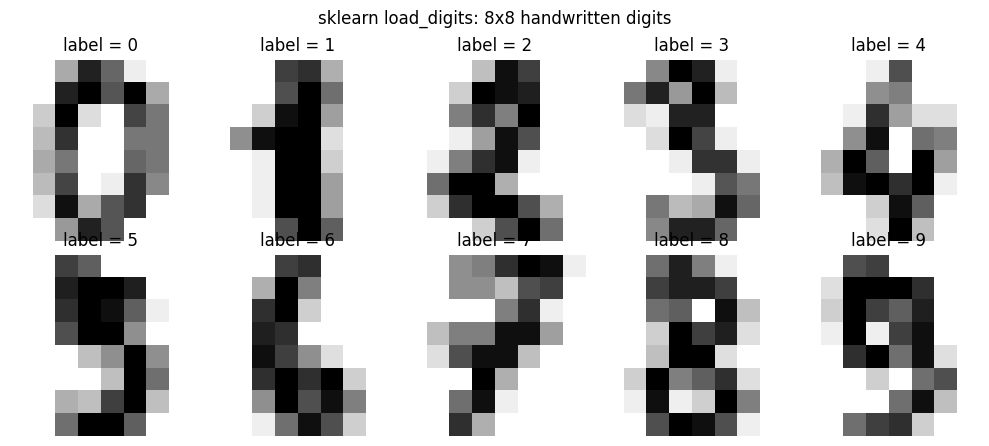


분할 결과  train: (1078, 64)  val: (359, 64)  test: (360, 64)
표준화 후 train 평균/표준편차 (전체 픽셀 기준): 0.0000 / 0.9763
표준화 후 test  평균/표준편차 (전체 픽셀 기준): -0.0004 / 0.9287   <- 정확히 0/1이 아닌 것이 정상

텐서 변환 완료: torch.Size([1078, 64]) torch.Size([1078]) torch.int64


In [22]:
# ── 1.1 데이터 확인 & 분할 ─────────────────────────────────────

# (1) 클래스별 개수 세기 — 한쪽으로 쏠려 있는가?
print("클래스별 샘플 수:", np.bincount(y))     # TODO: 정답 배열을 넣어 클래스별 개수를 센다
print("가장 많은 클래스 / 가장 적은 클래스:", np.bincount(y).max(), "/", np.bincount(y).min())

# (2) 이미지 10장 눈으로 확인 (보일러플레이트 — 그대로 두세요)
fig, axes = plt.subplots(2, 5, figsize=(10, 4.5))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(digits.images[i], cmap="gray_r")
    ax.set_title(f"label = {y[i]}")
    ax.axis("off")
plt.suptitle("sklearn load_digits: 8x8 handwritten digits")
plt.tight_layout()
plt.show()

# (3) train : val : test = 60 : 20 : 20 으로 두 번에 걸쳐 분할
#     stratify=... 를 주면 각 세트의 클래스 비율이 원본과 같게 유지된다.
# TODO: 먼저 전체를 train(60%) / 임시(40%)로 나눈다. random_state 는 MY_SEED.
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.4, random_state=MY_SEED, stratify=y
)
# TODO: 임시(40%)를 다시 반으로 갈라 val(20%) / test(20%)로 만든다.
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.5, random_state=MY_SEED, stratify=y_tmp
)
print("\n분할 결과  train:", X_train.shape, " val:", X_val.shape, " test:", X_test.shape)

# (4) 표준화 — 평균/표준편차는 반드시 train 에서만 학습(fit)한다!
scaler = StandardScaler()
# TODO: train 에만 fit 하고, 세 세트 모두 transform 한다. (fit_transform 을 val/test 에 쓰면 누수!)
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print("표준화 후 train 평균/표준편차 (전체 픽셀 기준): "
      f"{X_train_s.mean():.4f} / {X_train_s.std():.4f}")
print("표준화 후 test  평균/표준편차 (전체 픽셀 기준): "
      f"{X_test_s.mean():.4f} / {X_test_s.std():.4f}   <- 정확히 0/1이 아닌 것이 정상")

# (5) PyTorch 텐서로 변환 (실수형 X, 정수형 라벨 y)
Xtr = torch.tensor(X_train_s, dtype=torch.float32); ytr = torch.tensor(y_train, dtype=torch.long)
Xva = torch.tensor(X_val_s,   dtype=torch.float32); yva = torch.tensor(y_val,   dtype=torch.long)
Xte = torch.tensor(X_test_s,  dtype=torch.float32); yte = torch.tensor(y_test,  dtype=torch.long)
print("\n텐서 변환 완료:", Xtr.shape, ytr.shape, ytr.dtype)

**해석 질문 1.1 (본인이 출력한 실제 값을 인용해 답하세요)**

1. train / val / test 각각 몇 개의 샘플이 배정되었나요? 클래스별 개수(`np.bincount(y)`)를 보고, 이 데이터가 1주차 Framingham의 `TenYearCHD`(양성 약 15%)처럼 **불균형**한지 아닌지 판단하세요. 불균형하지 않다면, "무조건 한 클래스로만 찍는" 모델의 정확도는 몇 % 정도일까요? `전체 1797개 샘플은 train 1078개, validation 359개, test 360개로 분할되었다. 클래스별 샘플 수는 최소 174개, 최대 183개로 큰 차이가 없으므로 균형 잡힌 데이터이다. 가장 많은 클래스 하나만 항상 예측하면 정확도는 10.18% 정도이다.`

2. `X_test_s`의 평균이 정확히 0이 **아닌** 이유는 무엇인가요? 만약 `scaler.fit_transform(X_test)` 로 test에도 따로 fit 했다면 평균은 0이 되었을 텐데, 그렇게 하면 **왜 안 되는지** '데이터 누수' 개념으로 설명하세요. `X_test_s의 평균이 정확히 0이 아닌 이유는 StandardScaler가 train 데이터의 평균과 표준편차만 학습한 후 이것읆 test 데이터에 적용했기 때문이다. Train과 test의 데이터 분포가 완전히 같지는 않아서 test의 평균은 -0.0004, 표준편차는 0.9287로 나타났다. Test에 fit_transform()을 따로 사용하면 test 데이터의 통계 정보를 미리 이용하게 되어 데이터 누수가 발생하고, 실제 새로운 데이터에 대한 성능을 공정하게 평가할 수 없게 된다.`

3. train / val / test **세 덩어리**가 필요한 이유를, 강의 p.40 **Early Stopping**과 연결해 한 문장으로 쓰세요. (힌트: 멈출 시점을 무엇으로 고르고, 최종 성적표는 무엇으로 매기는가?) `Train 데이터는 모델의 가중치를 학습하는 데 사용하고, validation 데이터는 Early Stopping의 중단 시점과 최적 모델을 선택하는 데 사용하고, test 데이터는 선택이 모두 끝난 뒤 최종 일반화 성능을 한 번만 평가하는 데 사용하기 때문에 세 데이터셋을 분리해야 한다.`

---

### 1.2 PyTorch로 MLP 학습하기 — 미니배치 SGD 루프를 직접 채우기

§1.1에서 준비한 데이터를 이용해 이제 **PyTorch MLP를 직접 학습**합니다. 모델과 손실 함수는 PyTorch가 제공하지만, 강의 p.47의 **미니배치 SGD 4단계**는 직접 코드로 완성합니다.

> **Loop:**
> 1. **미니배치 샘플링** — 전체 학습 데이터에서 일부를 미니배치로 추출
> 2. **순전파 및 손실 계산** — 미니배치를 모델에 입력하여 예측값과 손실을 계산
> 3. **역전파** — 손실을 기준으로 각 파라미터의 기울기를 계산
> 4. **파라미터 업데이트** — 계산된 기울기의 반대 방향으로 파라미터를 업데이트

이 네 단계는 PyTorch 코드와 거의 그대로 대응됩니다.

| 강의 단계 | PyTorch 코드 |
|---|---|
| 1. 미니배치 샘플링 | `for xb, yb in loader:` (DataLoader가 대신 수행) |
| 2. 순전파 + 손실 | `loss = criterion(model(xb), yb)` |
| 3. 역전파 | `loss.backward()` |
| 4. 업데이트 | `optimizer.step()` |
| (+) 기울기 초기화 | `optimizer.zero_grad()` ← **매 스텝 맨 앞에!** |

⚠️ **`optimizer.zero_grad()`를 빠뜨리면** PyTorch는 gradient를 덮어쓰지 않고 **누적**합니다. 이전 미니배치의 기울기가 계속 더해져 학습이 의도와 다르게 진행되므로, 순서(`zero_grad → forward/loss → backward → step`)를 기억하세요.

**`nn.CrossEntropyLoss`의 주의점** — 이 함수는 내부에서 softmax와 cross entropy 계산을 함께 처리합니다. 따라서 모델의 마지막 층은 **`nn.Linear`로 끝내고 softmax를 따로 붙이지 않습니다.** softmax를 추가하면 같은 변환이 중복되어 학습 성능이 나빠질 수 있습니다.

**`model.train()` / `model.eval()`** — Dropout(§1.4)처럼 학습할 때와 평가할 때 **동작이 달라지는 층**이 있으므로 모드를 명시해야 합니다. `torch.no_grad()`는 평가 중 gradient 계산 그래프를 만들지 않아 메모리 사용량과 계산량을 줄입니다.

**이번 절의 모델 (강의 p.28 표대로):** `Input 64` → `Hidden 64 (ReLU)` → `Hidden 32 (ReLU)` → `Output 10`


In [23]:
# ── 1.2 공용 도구: 모델 빌더 · 평가 함수 · 학습 루프 ────────────
# 여기서 만든 세 함수는 §1.3 ~ §2 에서 계속 재사용합니다.

criterion = nn.CrossEntropyLoss()   # softmax 를 내부에 포함! 모델 끝에 softmax 붙이지 말 것

def build_mlp(hidden=(64, 32), act=nn.ReLU, in_dim=64, out_dim=10, p_drop=0.0, seed=MY_SEED):
    """(입력) -> [Linear -> act -> (Dropout)] x len(hidden) -> Linear(출력) 구조의 MLP."""
    torch.manual_seed(seed)          # 초기화 재현성
    layers, prev = [], in_dim
    for hdim in hidden:
        # TODO: Linear(prev -> hdim) 과 활성화 함수 act() 를 차례로 추가하라
        layers += [nn.Linear(prev, hdim), act()]
        if p_drop > 0:
            layers.append(nn.Dropout(p_drop))
        prev = hdim
    # TODO: 마지막 출력층 (활성화 함수 없이 Linear 로 끝낸다 — CrossEntropyLoss 가 softmax 담당)
    layers.append(nn.Linear(prev, out_dim))
    return nn.Sequential(*layers)

@torch.no_grad()                     # 평가 중에는 gradient 를 만들지 않는다
def evaluate(model, X, y):
    """(loss, accuracy) 를 돌려준다."""
    # TODO: 평가 모드로 전환 (Dropout 등을 끈다)
    model.eval()
    out = model(X)
    loss = criterion(out, y).item()
    # TODO: 가장 확률이 큰 클래스를 예측으로 삼아 정확도를 구하라 (힌트: out.argmax(1))
    acc = (out.argmax(dim=1) == y).float().mean().item()
    return loss, acc

def train_model(model, Xt=Xtr, yt=ytr, Xv=Xva, yv=yva, epochs=60,
                opt_name="adam", lr=1e-3, weight_decay=0.0, batch_size=64, seed=MY_SEED):
    """미니배치 SGD 루프. epoch 마다 train/val 의 loss·accuracy 를 기록해 돌려준다."""
    torch.manual_seed(seed)

    # ── optimizer 선택 (§1.5 에서 이 세 가지를 비교합니다) ──
    if opt_name == "sgd":
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif opt_name == "momentum":
        # TODO: SGD 에 momentum=0.9 를 주어 강의 p.48 의 Momentum 을 만든다
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    elif opt_name == "adam":
        # TODO: Adam optimizer 를 만든다 (lr, weight_decay 전달)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        raise ValueError(opt_name)

    g = torch.Generator().manual_seed(seed)          # 셔플 순서 재현
    loader = DataLoader(TensorDataset(Xt, yt), batch_size=batch_size, shuffle=True, generator=g)

    hist = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    for ep in range(epochs):
        model.train()                                 # 학습 모드
        for xb, yb in loader:                         # [단계1] 미니배치 샘플링
            # TODO [+] 이전 스텝의 gradient 를 0으로 초기화
            optimizer.zero_grad()
            # TODO [단계2] 순전파 + 손실 계산
            loss = criterion(model(xb), yb)
            # TODO [단계3] 역전파 — 각 파라미터의 gradient 계산
            loss.backward()
            # TODO [단계4] gradient 반대 방향으로 파라미터 업데이트
            optimizer.step()

        tl, ta = evaluate(model, Xt, yt)
        vl, va = evaluate(model, Xv, yv)
        hist["train_loss"].append(tl); hist["val_loss"].append(vl)
        hist["train_acc"].append(ta);  hist["val_acc"].append(va)
    return hist

def count_params(model):
    return sum(p.numel() for p in model.parameters())

def plot_curves(hist_dict, title, metric="loss"):
    """{이름: hist} 를 받아 train(점선)/val(실선) 곡선을 겹쳐 그린다."""
    plt.figure(figsize=(7, 4.2))
    for name, h in hist_dict.items():
        line, = plt.plot(h[f"val_{metric}"], label=f"{name} (val)")
        plt.plot(h[f"train_{metric}"], linestyle="--", alpha=0.6,
                 color=line.get_color(), label=f"{name} (train)")
    plt.xlabel("epoch"); plt.ylabel(metric); plt.title(title)
    plt.legend(fontsize=8); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

print("도구 준비 완료:", build_mlp, evaluate, train_model, sep="\n  ")

도구 준비 완료:
  <function build_mlp at 0x7b0d5a443560>
  <function evaluate at 0x7b0d5a443600>
  <function train_model at 0x7b0d5cee63e0>


In [11]:
# ── optimizer.zero_grad() 지우고 실행해보기 ────────────
# 여기서 만든 세 함수는 §1.3 ~ §2 에서 계속 재사용합니다.

criterion = nn.CrossEntropyLoss()   # softmax 를 내부에 포함! 모델 끝에 softmax 붙이지 말 것

def build_mlp(hidden=(64, 32), act=nn.ReLU, in_dim=64, out_dim=10, p_drop=0.0, seed=MY_SEED):
    """(입력) -> [Linear -> act -> (Dropout)] x len(hidden) -> Linear(출력) 구조의 MLP."""
    torch.manual_seed(seed)          # 초기화 재현성
    layers, prev = [], in_dim
    for hdim in hidden:
        # TODO: Linear(prev -> hdim) 과 활성화 함수 act() 를 차례로 추가하라
        layers += [nn.Linear(prev, hdim), act()]
        if p_drop > 0:
            layers.append(nn.Dropout(p_drop))
        prev = hdim
    # TODO: 마지막 출력층 (활성화 함수 없이 Linear 로 끝낸다 — CrossEntropyLoss 가 softmax 담당)
    layers.append(nn.Linear(prev, out_dim))
    return nn.Sequential(*layers)

@torch.no_grad()                     # 평가 중에는 gradient 를 만들지 않는다
def evaluate(model, X, y):
    """(loss, accuracy) 를 돌려준다."""
    # TODO: 평가 모드로 전환 (Dropout 등을 끈다)
    model.eval()
    out = model(X)
    loss = criterion(out, y).item()
    # TODO: 가장 확률이 큰 클래스를 예측으로 삼아 정확도를 구하라 (힌트: out.argmax(1))
    acc = (out.argmax(dim=1) == y).float().mean().item()
    return loss, acc

def train_model(model, Xt=Xtr, yt=ytr, Xv=Xva, yv=yva, epochs=60,
                opt_name="adam", lr=1e-3, weight_decay=0.0, batch_size=64, seed=MY_SEED):
    """미니배치 SGD 루프. epoch 마다 train/val 의 loss·accuracy 를 기록해 돌려준다."""
    torch.manual_seed(seed)

    # ── optimizer 선택 (§1.5 에서 이 세 가지를 비교합니다) ──
    if opt_name == "sgd":
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif opt_name == "momentum":
        # TODO: SGD 에 momentum=0.9 를 주어 강의 p.48 의 Momentum 을 만든다
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    elif opt_name == "adam":
        # TODO: Adam optimizer 를 만든다 (lr, weight_decay 전달)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        raise ValueError(opt_name)

    g = torch.Generator().manual_seed(seed)          # 셔플 순서 재현
    loader = DataLoader(TensorDataset(Xt, yt), batch_size=batch_size, shuffle=True, generator=g)

    hist = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    for ep in range(epochs):
        model.train()                                 # 학습 모드
        for xb, yb in loader:                         # [단계1] 미니배치 샘플링
            # TODO [+] 이전 스텝의 gradient 를 0으로 초기화
            #optimizer.zero_grad()
            # TODO [단계2] 순전파 + 손실 계산
            loss = criterion(model(xb), yb)
            # TODO [단계3] 역전파 — 각 파라미터의 gradient 계산
            loss.backward()
            # TODO [단계4] gradient 반대 방향으로 파라미터 업데이트
            optimizer.step()

        tl, ta = evaluate(model, Xt, yt)
        vl, va = evaluate(model, Xv, yv)
        hist["train_loss"].append(tl); hist["val_loss"].append(vl)
        hist["train_acc"].append(ta);  hist["val_acc"].append(va)
    return hist

def count_params(model):
    return sum(p.numel() for p in model.parameters())

def plot_curves(hist_dict, title, metric="loss"):
    """{이름: hist} 를 받아 train(점선)/val(실선) 곡선을 겹쳐 그린다."""
    plt.figure(figsize=(7, 4.2))
    for name, h in hist_dict.items():
        line, = plt.plot(h[f"val_{metric}"], label=f"{name} (val)")
        plt.plot(h[f"train_{metric}"], linestyle="--", alpha=0.6,
                 color=line.get_color(), label=f"{name} (train)")
    plt.xlabel("epoch"); plt.ylabel(metric); plt.title(title)
    plt.legend(fontsize=8); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

print("도구 준비 완료:", build_mlp, evaluate, train_model, sep="\n  ")

도구 준비 완료:
  <function build_mlp at 0x7b0d5cd000e0>
  <function evaluate at 0x7b0d5a89d120>
  <function train_model at 0x7b0d5f410860>


Sequential(
  (0): Linear(in_features=64, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=10, bias=True)
)
파라미터 수: 6570


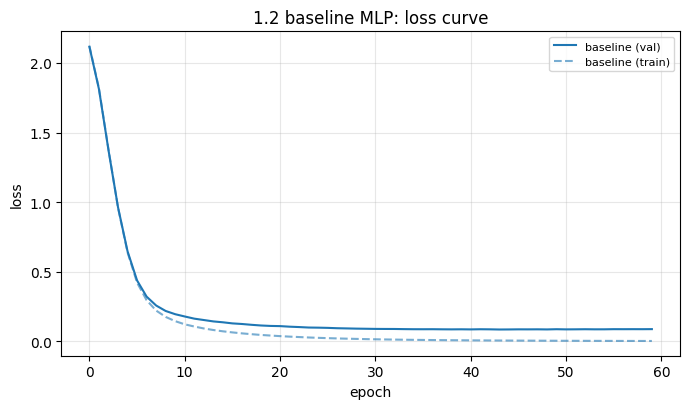

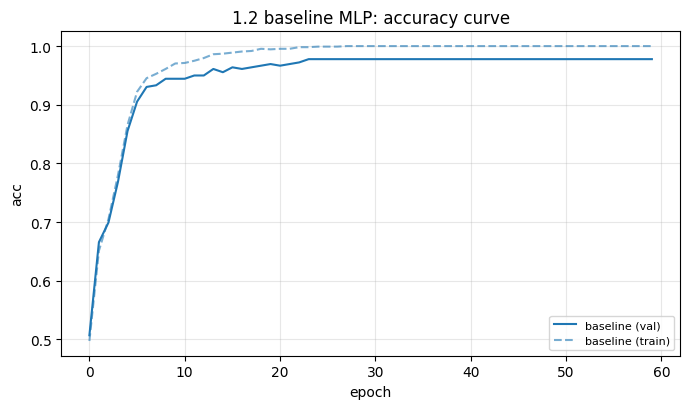


[최종] test loss = 0.1051 | test accuracy = 0.9722
val_loss 최저 epoch = 44 (val_loss = 0.0852)
마지막 epoch 의 train_loss = 0.0028 / val_loss = 0.0879
train_acc = 1.0000 / val_acc = 0.9777


In [24]:
# ── 1.2 baseline MLP 학습: 64 -> 64 -> 32 -> 10 ────────────────
baseline = build_mlp(hidden=(64, 32), act=nn.ReLU)
print(baseline)
print("파라미터 수:", count_params(baseline))

hist_base = train_model(baseline, epochs=60, opt_name="adam", lr=1e-3)

# 학습 곡선 (강의 p.40 Early Stopping 그림과 같은 형태가 나오는지 보세요)
plot_curves({"baseline": hist_base}, "1.2 baseline MLP: loss curve", metric="loss")
plot_curves({"baseline": hist_base}, "1.2 baseline MLP: accuracy curve", metric="acc")

# TODO: 마지막에 딱 한 번, test 세트로 최종 성능을 측정하라
test_loss, test_acc = evaluate(baseline, Xte, yte)
print(f"\n[최종] test loss = {test_loss:.4f} | test accuracy = {test_acc:.4f}")

# TODO: val_loss 가 가장 낮았던 epoch 번호를 찾아라 (Early Stopping 이라면 여기서 멈췄을 것)
best_ep = int(np.argmin(hist_base["val_loss"])) + 1
print(f"val_loss 최저 epoch = {best_ep} (val_loss = {min(hist_base['val_loss']):.4f})")
print(f"마지막 epoch 의 train_loss = {hist_base['train_loss'][-1]:.4f} / "
      f"val_loss = {hist_base['val_loss'][-1]:.4f}")
print(f"train_acc = {hist_base['train_acc'][-1]:.4f} / val_acc = {hist_base['val_acc'][-1]:.4f}")

Sequential(
  (0): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=10, bias=True)
  )
  (1): Softmax(dim=1)
)
기존 모델   | test loss = 0.1051 | test accuracy = 0.9722
Softmax 추가 | test loss = 1.5016 | test accuracy = 0.9639


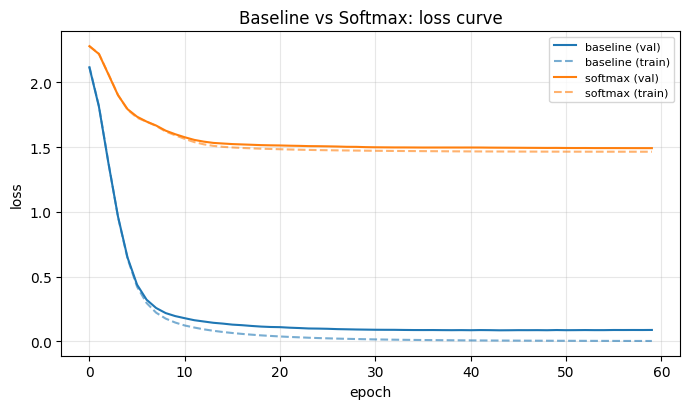

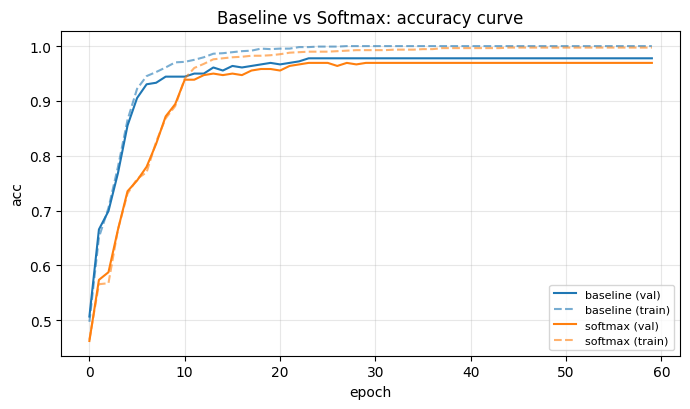

In [25]:
# 기존 MLP 뒤에 Softmax를 추가한 실험 모델
softmax_model = nn.Sequential(
    build_mlp(
        hidden=(64, 32),
        act=nn.ReLU,
        seed=MY_SEED
    ),
    nn.Softmax(dim=1)
)

print(softmax_model)

# 동일한 조건으로 처음부터 학습
hist_softmax = train_model(
    softmax_model,
    epochs=60,
    opt_name="adam",
    lr=1e-3
)

# Test 성능 측정
softmax_test_loss, softmax_test_acc = evaluate(
    softmax_model,
    Xte,
    yte
)

print(f"기존 모델   | test loss = {test_loss:.4f} "
      f"| test accuracy = {test_acc:.4f}")

print(f"Softmax 추가 | test loss = {softmax_test_loss:.4f} "
      f"| test accuracy = {softmax_test_acc:.4f}")

plot_curves(
    {
        "baseline": hist_base,
        "softmax": hist_softmax
    },
    "Baseline vs Softmax: loss curve",
    metric="loss"
)

plot_curves(
    {
        "baseline": hist_base,
        "softmax": hist_softmax
    },
    "Baseline vs Softmax: accuracy curve",
    metric="acc"
)

**해석 질문 1.2 (본인 출력값 인용)**

1. 이 모델의 **파라미터 수**는 몇 개인가요? 손으로도 계산해 확인하세요: $64{\times}64+64$, $64{\times}32+32$, $32{\times}10+10$ 의 합과 같은가요? (bias를 빠뜨리지 마세요.) `모델의 전체 파라미터 수는 6,570개이다. 각 층의 파라미터 수는 첫 번째 층이 4160개, 두 번째 층이 2080개, 출력층이 330개이므로 총합은 6570개이다. 코드로 출력한 값과 일치한다.`

2. 본인의 **test accuracy**를 적으세요. §1.1에서 계산한 "무조건 한 클래스로 찍기" 정확도와 비교하면 얼마나 나은가요? `test accuracy는 0.9722이다. 학습한 MLP가 하나의 클래스로 찍는 것보다 87.04% 높은 정확도를 보였다. 따라서 모델이 단순히 특정 클래스만 출력한 것이 아니라 숫자 이미지의 특징을 제대로 학습했다고 볼 수 있다.`

3. **loss 곡선을 보세요.** train loss는 계속 내려가는데 val loss는 어느 지점부터 더 내려가지 않거나 **살짝 올라가기 시작**했을 것입니다. 그 지점(대략 몇 epoch)과, 그때 train/val loss 값을 적으세요. 이 그림이 강의 p.40 Early Stopping 슬라이드의 그림과 어떻게 대응되는지 설명하세요. `Train loss는 학습이 진행될수록 계속 감소하여 마지막에는 0.0028까지 낮아졌지만, validation loss는 약 20~30 epoch 사이부터 감소 폭이 매우 작아지며 정체되었다. Validation loss는 44 epoch에서 0.0852로 최저점을 기록한 뒤 조금씩 증가하여 마지막에는 0.0879가 되었다. 또한 train accuracy는 1.0000에 도달했지만 validation accuracy는 0.9777에 머물렀으므로, 후반부에는 과적합이 발생했다고 볼 수 있다. Early Stopping을 적용한다면 validation loss가 더 이상 개선되지 않는지를 관찰하고, 최저 loss를 기록한 44 epoch의 모델을 저장하여 최종 모델로 사용해야 한다.`

4. `optimizer.zero_grad()` 를 **일부러 지우고** 다시 실행해 보세요(다른 셀에 복사해서 실험할 것). 학습 곡선이 어떻게 달라졌나요? PyTorch가 gradient를 **누적**한다는 사실과 연결해 설명하세요. `Train loss는 마지막에 0.0226까지 감소했지만, validation loss는 6 epoch에서 0.3343으로 최저점을 기록한 후 크게 흔들리면서 마지막에는 2.2888까지 증가하였다. Test loss도 기존 0.1051에서 6.7994로 크게 증가했고, test accuracy는 0.9722에서 0.9222로 감소하였다. PyTorch의 loss.backward()는 새로운 gradient로 기존 gradient를 대체하지 않고 계속 더하여 누적한다. 따라서 zero_grad()를 호출하지 않으면 이전 미니배치의 gradient까지 누적되어 파라미터가 지나치게 크게 갱신되고, 학습이 불안정해지며 과적합과 일반화 성능 저하가 발생한다.`

5. 모델 마지막에 `nn.Softmax(dim=1)` 을 추가하면 어떻게 될지 예상하고, 실제로 추가해 성능을 비교해 보세요. (힌트: `nn.CrossEntropyLoss`는 이미 softmax를 품고 있습니다.) `모델 마지막에 Softmax를 추가하면 cross entropy loss 내부에서 다시 softmax에 해당하는 연산이 적용되므로 학습이 느려지고 loss가 충분히 감소하지 않을 것으로 예상하였다. 실험 결과, 기존 모델은 test loss가 0.1051, test accuracy가 0.9722였지만, softmax를 추가한 모델은 test loss가 1.5016, test accuracy가 0.9639로 나타났다. softmax 모델의 정확도는 기존 모델보다 0.0083감소했으며, test loss는 크게 증가하였다. 학습 곡선에서도 기존 모델의 loss는 0에 가깝게 감소했지만 softmax 모델의 loss는 약 1.5에서 더 이상 충분히 감소하지 않았다. 따라서 nn.CrossEntropyLoss를 사용할 때는 모델의 마지막 층에 softmax를 추가하지 않고 linear가 출력한 logits를 그대로 전달해야 한다.`

---

### 1.3 Issue 1) Vanishing Gradient — 강의의 주장을 gradient로 직접 재기

강의 4장은 "Deep architecture는 input에서 output까지 gradient chain이 길어서 **Vanishing Gradient**가 생기고, 처방은 **non-saturating 활성화 함수(ReLU 계열)**"라고 말합니다(p.37~38). 여기서는 그 말을 **숫자로 확인**합니다.

**실험 설계**

- 은닉층 **8개**(width 32)를 쌓은 깊은 MLP를 두 개 만듭니다. **딱 하나만 다릅니다: 활성화 함수가 Sigmoid냐 ReLU냐.**
- 아직 **학습은 하지 않고**, 초기 파라미터에서 **역전파를 딱 한 번** 돌립니다.
- 그리고 **각 층 가중치의 gradient 크기(L2 norm)** 를 재서, 출력층에서 입력층으로 갈수록 얼마나 작아지는지 봅니다.
- 마지막으로 두 네트워크를 실제로 40 epoch 학습시켜 **성능 차이**를 확인합니다.

**왜 gradient의 norm인가?** gradient가 0에 가깝다는 것은 "이 층의 가중치를 아무리 바꿔도 loss가 거의 안 변한다 → **업데이트 신호가 없다 → 학습이 안 된다**"는 뜻입니다. Sigmoid를 한 번 지날 때마다 도함수 $h(1-h) \le 0.25$가 곱해지므로, 층이 깊어질수록 앞쪽 층의 gradient는 기하급수적으로 줄어듭니다.

> 📌 **이 절의 결과가 강의 마지막 서술형 퀴즈의 답입니다.** 그래프를 캡처해 기술블로그에 넣고, "chain rule 관점에서 왜 사라지는가"를 본인 숫자로 설명하세요.

층 번호 1 = 입력에 가장 가까운 층,  마지막 = 출력층

[Sigmoid]  2.32e-07 4.49e-07 2.85e-06 1.50e-05 1.00e-04 8.07e-04 6.34e-03 4.26e-02 2.68e-01
[ReLU]     8.48e-04 5.74e-04 5.87e-04 5.93e-04 6.45e-04 1.79e-03 4.67e-03 1.01e-02 1.79e-02

Sigmoid: 마지막층 / 첫번째층 = 1.156e+06 배
ReLU   : 마지막층 / 첫번째층 = 2.115e+01 배


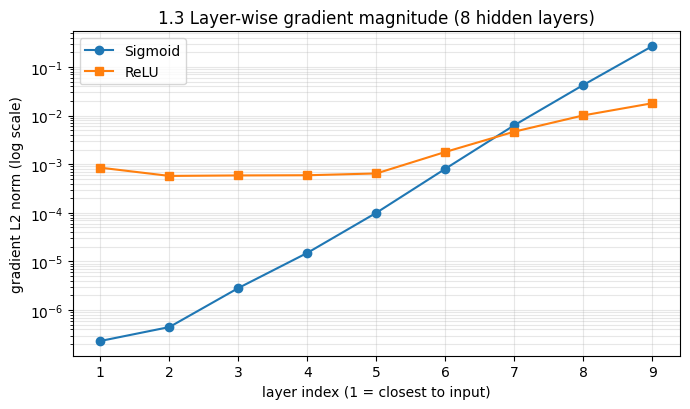

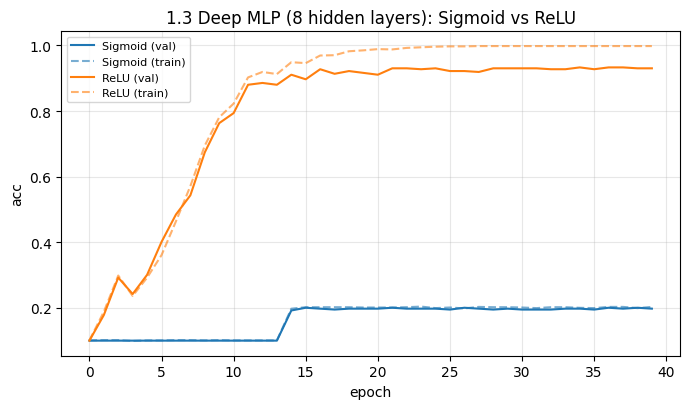


[Sigmoid 8층] 최종 train_acc = 0.2032 / val_acc = 0.1978
[ReLU    8층] 최종 train_acc = 0.9981 / val_acc = 0.9304
[참고: 1.2 얕은 2층 ReLU] val_acc = 0.9777


In [26]:
# ── 1.3 Vanishing Gradient 측정 ────────────────────────────────

def build_deep(act, depth=8, width=32, seed=MY_SEED):
    """은닉층을 depth 개 쌓은 깊은 MLP. act 만 바꿔 가며 비교한다."""
    torch.manual_seed(seed)
    layers, prev = [], 64
    for _ in range(depth):
        layers += [nn.Linear(prev, width), act()]
        prev = width
    layers.append(nn.Linear(prev, 10))
    return nn.Sequential(*layers)

def layerwise_grad_norms(model, X, y):
    """역전파를 한 번 돌리고, 각 Linear 층 weight 의 gradient L2 norm 을 리스트로 돌려준다."""
    model.train()
    model.zero_grad()
    loss = criterion(model(X), y)
    # TODO: 역전파를 수행해 각 파라미터의 .grad 를 채워라
    loss.backward()
    norms = []
    for name, param in model.named_parameters():
        if name.endswith("weight"):
            # TODO: 이 층 gradient 의 L2 norm 을 float 로 담아라 (힌트: param.grad.norm().item())
            norms.append(param.grad.norm().item())
    return norms

# (1) 활성화 함수만 바꾼 두 깊은 네트워크의 층별 gradient 크기 비교
# TODO: 각각 nn.Sigmoid / nn.ReLU 를 넣어라 (클래스 자체를 넘긴다, 괄호 없이!)
deep_sig  = build_deep(act=nn.Sigmoid)
deep_relu = build_deep(act=nn.ReLU)

norms_sig  = layerwise_grad_norms(deep_sig,  Xtr, ytr)
norms_relu = layerwise_grad_norms(deep_relu, Xtr, ytr)

print("층 번호 1 = 입력에 가장 가까운 층,  마지막 = 출력층\n")
print("[Sigmoid] ", " ".join(f"{v:.2e}" for v in norms_sig))
print("[ReLU]    ", " ".join(f"{v:.2e}" for v in norms_relu))
print(f"\nSigmoid: 마지막층 / 첫번째층 = {norms_sig[-1] / norms_sig[0]:.3e} 배")
print(f"ReLU   : 마지막층 / 첫번째층 = {norms_relu[-1] / norms_relu[0]:.3e} 배")

# (2) 층별 gradient 크기 그래프 (y축은 log scale 이어야 차이가 보인다)
plt.figure(figsize=(7, 4.2))
layer_idx = np.arange(1, len(norms_sig) + 1)
plt.semilogy(layer_idx, norms_sig,  "o-", label="Sigmoid")
plt.semilogy(layer_idx, norms_relu, "s-", label="ReLU")
plt.xlabel("layer index (1 = closest to input)")
plt.ylabel("gradient L2 norm (log scale)")
plt.title("1.3 Layer-wise gradient magnitude (8 hidden layers)")
plt.legend(); plt.grid(alpha=0.3, which="both"); plt.tight_layout(); plt.show()

# (3) 실제로 학습시켜 성능 차이 확인 (40 epoch)
hist_sig  = train_model(build_deep(act=nn.Sigmoid), epochs=40)
hist_relu = train_model(build_deep(act=nn.ReLU),    epochs=40)
plot_curves({"Sigmoid": hist_sig, "ReLU": hist_relu},
            "1.3 Deep MLP (8 hidden layers): Sigmoid vs ReLU", metric="acc")

print(f"\n[Sigmoid 8층] 최종 train_acc = {hist_sig['train_acc'][-1]:.4f} / "
      f"val_acc = {hist_sig['val_acc'][-1]:.4f}")
print(f"[ReLU    8층] 최종 train_acc = {hist_relu['train_acc'][-1]:.4f} / "
      f"val_acc = {hist_relu['val_acc'][-1]:.4f}")
print(f"[참고: 1.2 얕은 2층 ReLU] val_acc = {hist_base['val_acc'][-1]:.4f}")

**해석 질문 1.3 (본인 출력값 인용)**

1. **Sigmoid 네트워크의 첫 번째 층과 마지막 층의 gradient norm**을 적고, 몇 배 차이인지 쓰세요. ReLU는 몇 배였나요? 두 배율을 나란히 비교해 한 문장으로 결론지으세요.

Sigmoid 네트워크의 첫 번째 층 gradient norm은 $2.32 \times 10^{-7}$이고 마지막 출력층은 $2.68 \times 10^{-1}$이다. 마지막 층의 gradient가 첫 번째 층보다 약 $1.156 \times 10^6$배 컸다. ReLU 네트워크의 첫 번째 층 gradient norm은 $8.48 \times 10^{-4}$이고 마지막 출력층은 $1.79 \times 10^{-2}$로 약 $2.115 \times 10^1$배 차이가 났다. 따라서 Sigmoid에서는 입력에 가까운 층의 gradient가 거의 사라졌지만 ReLU에서는 gradient가 상대적으로 잘 전달되었다.

2. Sigmoid의 도함수 $\sigma'(z) = h(1-h) \le 0.25$ 를 이용해, **왜 Sigmoid에서만 이런 일이 생기는지** chain rule 식으로 설명하세요. ReLU의 도함수는 양수 구간에서 얼마인가요? 그래서 어떻게 되나요?

역전파에서는 chain rule에 따라 각 층의 활성화 함수 미분값이 연속해서 곱해진다. Sigmoid의 도함수는 $$\sigma'(z)=\sigma(z)(1-\sigma(z))\leq0.25$$ 이다. 반면 ReLU의 도함수는 입력이 양수이면 1이고 음수이면 0이다. 활성화된 뉴런에서는 미분값이 1이므로 여러 층을 통과해도 Sigmoid처럼 gradient가 반복적으로 작아지지 않는다. 다만 입력이 음수인 뉴런에는 gradient가 0이 되어 학습되지 않는 dead ReLU 문제가 발생할 수 있다.

3. 학습 결과: Sigmoid 8층과 ReLU 8층의 최종 **train accuracy**를 적으세요. Sigmoid 쪽은 **train accuracy조차** 낮게 나왔을 것입니다. 이것이 과적합(overfitting) 문제와는 **완전히 다른 종류의 실패**인 이유를 설명하세요. (힌트: 과적합은 "train은 잘하는데 val이 나쁜" 것입니다.)

Sigmoid 8층 모델의 최종 train accuracy는 0.2032이고 validation accuracy는 0.1978이었다. ReLU 8층 모델은 train accuracy가 0.9981이고 validation accuracy가 0.9304였다. Sigmoid 모델은 train과 validation 정확도가 모두 약 20%로 낮으므로 과적합이 아니다. 과적합은 train 성능은 높지만 validation 성능은 낮은 경우를 의미한다. Sigmoid 모델은 vanishing gradient 때문에 입력에 가까운 층의 파라미터가 충분히 갱신되지 못한 최적화 실패 또는 underfitting에 해당한다.


4. §1.2의 **얕은(2층) ReLU** 모델의 val accuracy와 §1.3의 **깊은(8층) ReLU** 모델을 비교하세요. 층을 4배로 늘렸는데 성능이 좋아졌나요? 예상과 다르다면 그 원인으로 무엇을 의심하겠습니까? (§2-B에서 이어서 다룹니다.)

2층 ReLU 모델의 validation accuracy는 0.9777이지만 8층 ReLU 모델은 0.9304였다. 층을 4배로 늘렸음에도 성능은 0.0473 즉 4.73%p 감소하였다. 깊은 모델은 표현력이 더 크지만 gradient 전달과 최적화가 어렵다. 또한 현재 구조에는 Batch Normalization이나 residual connection처럼 깊은 네트워크의 학습을 안정화하는 장치가 없다. 8층 모델은 train accuracy가 0.9981로 매우 높은 반면 validation accuracy는 0.9304이므로 과적합도 일부 발생하였다. 따라서 모델을 깊게 만드는 것만으로 성능이 자동으로 향상되지는 않는다.

#### 5.

5. **강의 서술형 퀴즈에 답하세요.** "Sigmoid를 hidden layer의 활성화 함수로 사용한 DNN에서 vanishing gradient가 발생하는 이유를 backpropagation의 chain rule 관점에서 설명하고, 이를 해결하는 방법을 **2가지 이상** 제시하시오." — 본인이 방금 잰 숫자를 근거로 인용해서 답하세요.

Sigmoid를 은닉층의 활성화 함수로 사용한 DNN에서 vanishing gradient가 발생하는 이유는 backpropagation의 chain rule 과정에서 1보다 작은 Sigmoid 도함수가 여러 층에 걸쳐 반복해서 곱해지기 때문이다. 이걸 해결하기 위해 Sigmoid 대신 ReLU나 Leaky ReLU를 사용할 수 있다. 또는 Batch Normalization, residual connection 등을 적용할 수 있다. 이러한 방법들은 gradient의 크기와 활성화값의 분포를 안정적으로 유지하여 깊은 층까지 학습이 이루어지도록 한다.


---

### 1.4 Issue 2) Overfitting — 네 가지 처방을 같은 조건에서 붙여 보기

강의 p.39는 과적합을 "Training error는 줄지만 Generalization 성능은 낮음 / **노이즈까지 기억하는** 상태"로 정의하고, 처방 네 가지를 제시했습니다.

| Remedy | 아이디어 | 이번 실험에서 |
|---|---|---|
| ① **Early Stopping** | val loss가 개선되지 않으면 중단 | `val_loss` 최저 epoch를 찾아 "여기서 멈췄어야 했다"를 확인 |
| ② **Data Augmentation** | label을 유지하는 노이즈 데이터로 robustness 향상 | (심화 §2-C에서 도전 가능) |
| ③ **L1/L2 Regularization** | `Loss = error + 모델 크기` | `weight_decay` 로 L2 적용, 강도 2단계 비교 |
| ④ **Dropout** | 매 스텝 유닛을 확률적으로 비활성화 | `p_drop=0.5` (강의 권장값: hidden 50%) |

**과적합을 일부러 만듭니다.** §1.2의 모델은 데이터가 충분해 과적합이 약했습니다. 그래서 이번엔 **훈련 데이터를 150개로 줄이고**(전체의 약 14%) 모델을 **256-256으로 키워** 극단적인 상황을 만듭니다. 데이터는 적고 파라미터는 많으니 모델이 150개를 통째로 외워 버리기 좋은 조건입니다.

**공정 비교의 원칙:** 네 조건에서 **바뀌는 것은 규제 하나뿐**이고 데이터·구조·시드·epoch 수는 모두 동일합니다. 그래야 차이의 원인을 규제로 돌릴 수 있습니다.

⚠️ **Dropout 주의:** `model.train()`일 때만 뉴런을 끄고, `model.eval()`에서는 모두 켠 채 스케일을 보정합니다(강의 p.43: "추론 시 출력에 p를 곱해 기댓값을 맞춘다"). §1.2에서 `evaluate()` 안에 `model.eval()`을 넣은 이유가 바로 이것입니다 — 빠뜨리면 평가할 때마다 결과가 달라집니다.

작은 훈련셋: torch.Size([150, 64]) | 원래 훈련셋: torch.Size([1078, 64])


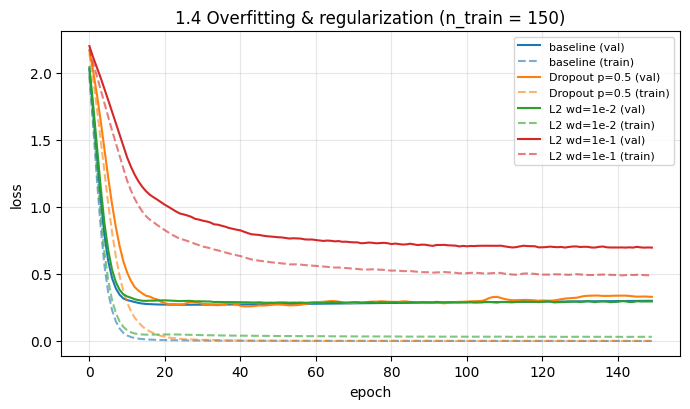

조건               train_loss  val_loss     gap  train_acc  val_acc  best_ep best_val_acc
----------------------------------------------------------------------------------------
baseline             0.0002    0.2996  0.2994     1.0000   0.9109       27       0.9220
Dropout p=0.5        0.0000    0.3292  0.3291     1.0000   0.9276       43       0.9331
L2 wd=1e-2           0.0310    0.2949  0.2639     1.0000   0.9220       62       0.9331
L2 wd=1e-1           0.4903    0.6964  0.2061     0.9800   0.8942      148       0.9025

[Early Stopping] baseline 은 epoch 27 에서 멈췄어야 했다. (실제로는 150 까지 돌렸으니 123 epoch 를 낭비)


In [27]:
# ── 1.4 과적합 만들고, 규제 네 가지 비교 ────────────────────────

# (1) 훈련 데이터를 150개로 줄여 과적합 상황을 만든다
rng = np.random.default_rng(MY_SEED)
# TODO: 훈련셋 인덱스 중 150개를 비복원추출하라 (힌트: rng.choice(len(Xtr), size=..., replace=False))
small_idx = rng.choice(len(Xtr),size=150,replace=False)
Xsm, ysm = Xtr[small_idx], ytr[small_idx]
print("작은 훈련셋:", Xsm.shape, "| 원래 훈련셋:", Xtr.shape)

# (2) 규제만 바꿔 가며 동일 조건으로 학습
#     (모델은 모두 64 -> 256 -> 256 -> 10, epochs=150, batch_size=32)
configs = [
    # (이름,            dropout 확률, L2 강도(weight_decay))
    ("baseline",        0.0,  0.0),
    ("Dropout p=0.5",   0.5,  0.0),
    ("L2 wd=1e-2",      0.0,  1e-2),
    ("L2 wd=1e-1",      0.0,  1e-1),
]

hist14 = {}
for name, p_drop, wd in configs:
    # TODO: hidden=(256, 256) 이고 dropout 확률이 p_drop 인 모델을 만들어라
    m = build_mlp(hidden=(256, 256), p_drop=p_drop)
    # TODO: 작은 훈련셋(Xsm, ysm)으로 150 epoch 학습. weight_decay 에 wd 를 전달할 것.
    hist14[name] = train_model(m, Xt=Xsm, yt=ysm, epochs=150,
                               weight_decay=wd, batch_size=32)

plot_curves(hist14, "1.4 Overfitting & regularization (n_train = 150)", metric="loss")

# (3) 요약표 — 과적합 정도(gap)와 Early Stopping 시점
print(f"{'조건':<16}{'train_loss':>11}{'val_loss':>10}{'gap':>8}"
      f"{'train_acc':>11}{'val_acc':>9}{'best_ep':>9}{'best_val_acc':>13}")
print("-" * 88)
for name, h in hist14.items():
    tl, vl = h["train_loss"][-1], h["val_loss"][-1]
    # TODO: val_loss 가 최소인 epoch (0-based index) 를 찾아라 -> Early Stopping 시점
    best = int(np.argmin(h["val_loss"]))
    print(f"{name:<16}{tl:>11.4f}{vl:>10.4f}{vl - tl:>8.4f}"
          f"{h['train_acc'][-1]:>11.4f}{h['val_acc'][-1]:>9.4f}"
          f"{best + 1:>9}{max(h['val_acc']):>13.4f}")

# (4) Early Stopping 을 썼다면 몇 epoch 를 아꼈을까?
best_base = int(np.argmin(hist14["baseline"]["val_loss"])) + 1
print(f"\n[Early Stopping] baseline 은 epoch {best_base} 에서 멈췄어야 했다. "
      f"(실제로는 150 까지 돌렸으니 {150 - best_base} epoch 를 낭비)")

**해석 질문 1.4 (본인 출력값 인용)**

1. **baseline이 과적합했다는 증거**를 세 가지 숫자로 대세요: 마지막 `train_loss`, `train_acc`, 그리고 `val_loss - train_loss` (gap). 강의 p.39의 정의("Training error는 줄지만 Generalization 성능은 낮음")와 대응시켜 한 문장으로 쓰세요.

Baseline 마지막 train loss는 0.0002이고 train accuracy는 1.0000이지만 validation loss는 0.2996이고 validation accuracy는 0.9109이다. 또한 validation loss와 train loss의 차이인 gap은 0.2994이다. 모델이 150개의 train 데이터를 거의 완벽하게 학습했지만 새로운 validation 데이터에서는 정확도가 낮아지는 과적합이다.

2. `val_loss`가 최소였던 epoch는 baseline에서 몇이었나요? 전체 150 epoch 중 **몇 %** 지점인가요? Early Stopping이 왜 "**공짜에 가까운** 규제"라 불리는지(추가 파라미터도, 구조 변경도 없음) 본인 숫자로 설명하세요.

Baseline의 validation loss는 27 epoch에서 최소가 되었다. 이는 전체 150 epoch 중 18%이다. Early Stopping을 적용했다면 27 epoch에서 학습을 멈출 수 있었으므로 123 epoch를 절약할 수 있었다. Early Stopping은 모델 구조를 변경하거나 별도의 규제항을 추가하지 않고 validation 성능이 더 이상 좋아지지 않는 시점에서 학습을 중단한다. 따라서 추가적인 추론 비용 없이 과적합을 줄이고 학습 시간도 절약할 수 있어 공짜에 가까운 규제라고 볼 수 있다.

3. **Dropout p=0.5의 결과를 정직하게 보고하세요.** 최종 `val_loss`는 baseline보다 좋아졌나요, 나빠졌나요? 반대로 `best_val_acc`는 어땠나요? **두 지표가 다른 방향을 가리킨다면** 그 이유를 추론해 보세요. (힌트: 정확도는 "맞힌 개수", loss는 "확신의 정확성"을 잽니다.)

Dropout을 적용한 모델의 마지막 validation loss는 0.3292로 baseline의 0.2996보다 커졌으므로 loss 기준으로는 나빠졌다. 반면 best validation accuracy는 baseline의 0.9220에서 Dropout의 0.9331로 높아졌다. Accuracy는 예측한 클래스가 정답인지 여부만 측정하지만 Cross Entropy Loss는 정답 클래스에 얼마나 높은 확률을 부여했는지까지 평가한다. 따라서 Dropout 모델이 더 많은 샘플의 클래스를 맞혔더라도 정답에 대한 확신이 낮거나 틀린 샘플에 지나치게 높은 확률을 부여했다면 loss는 더 커질 수 있다. 또한 최저 validation loss가 나온 epoch와 최고 validation accuracy가 나온 epoch가 서로 다를 수 있다.

4. **L2 강도를 10배로 키운 `wd=1e-1`** 에서는 무슨 일이 일어났나요? `train_acc`와 `val_acc`를 함께 보고, 이것이 과적합인지 **과소적합(underfitting)** 인지 판정하세요. "규제는 세게 걸수록 좋다"는 말이 왜 틀렸는지 본인 숫자로 반박하세요.

`weight_decay=1e-1`에서는 train accuracy가 0.9800이고 validation accuracy가 0.8942로 네 조건 중 validation 성능이 가장 낮았다. Train loss도 0.4903이고 validation loss도 0.6964로 다른 조건보다 크게 나타났다. 이건 L2 규제가 너무 강해서 모델의 가중치가 필요한 만큼 학습되지 못한 과소적합 또는 과도한 규제 상태이다. 이런 결과를 통해서 규제는 강할수록 항상 좋은 것이 아니며 데이터와 모델에 맞는 적절한 강도를 선택해야 한다는 것을 알 수 있다.

5. 네 조건 중 **본인 데이터에서 가장 좋았던 것**은 무엇인가요? 그 결과가 강의 슬라이드의 서술과 일치했나요, 어긋났나요? 어긋났다면 원인으로 무엇을 의심하겠습니까? (힌트: 훈련 샘플 150개에 뉴런의 절반을 끄면 어떻게 될까요?)

이 실험에서는 `L2 wd=1e-2`가 가장 균형 잡힌 결과를 보였다. Best validation accuracy는 0.9331로 Dropout과 공동으로 가장 높았고 마지막 validation loss는 0.2949로 네 조건 중 가장 낮았다. 또한 loss gap도 0.2639로 baseline의 0.2994보다 감소하였다. 적절한 규제가 과적합을 줄이고 generalization 성능을 높인다는 강의 내용과 대체로 일치한다. 하지만 Dropout과 L2의 best validation accuracy가 동일하고 모델 크기에 비해 훈련 샘플이 150개로 매우 적으므로 결과가 데이터와 random seed에 민감할 수 있다.

---

### 1.5 Issue 3) Optimization — SGD / Momentum / Adam을 같은 출발선에서

강의 p.45~50은 optimizer의 계보를 보여 줬습니다.

$$\text{GD} \to \text{SGD(minibatch)} \to \text{Momentum},\ \text{RMSProp} \to \text{Adam}$$

- **Mini-batch SGD**: 전체가 아닌 일부로 gradient를 계산해 **자주** 업데이트
- **Momentum**: `업데이트 = 현재 gradient + 과거 gradient` — 방향이 자주 바뀌는 축은 상쇄, 일관된 축은 가속 → 지그재그 완화, 안장점 탈출
- **Adaptive (AdaGrad → RMSProp)**: gradient가 컸던 파라미터는 학습률을 줄이고 작았던 파라미터는 키움
- **Adam**: Momentum(**방향**) + RMSProp(**크기**) = "어디로 + 얼마나"

**실험 설계** — 모델·데이터·시드·epoch를 완전히 고정하고 **optimizer만** 바꿉니다. 학습률이 optimizer마다 적정 범위가 다르므로, SGD 계열은 `lr=0.05`, Adam은 관례적 기본값 `lr=0.001`을 씁니다. 여기에 **일부러 학습률을 크게 준 `SGD lr=3.0`** 도 넣어 무슨 일이 벌어지는지 봅니다.

비교 지표는 두 가지입니다: **① 최종 성능**(어디까지 갔나)과 **② 수렴 속도**(val accuracy 90%에 몇 epoch만에 도달했나).

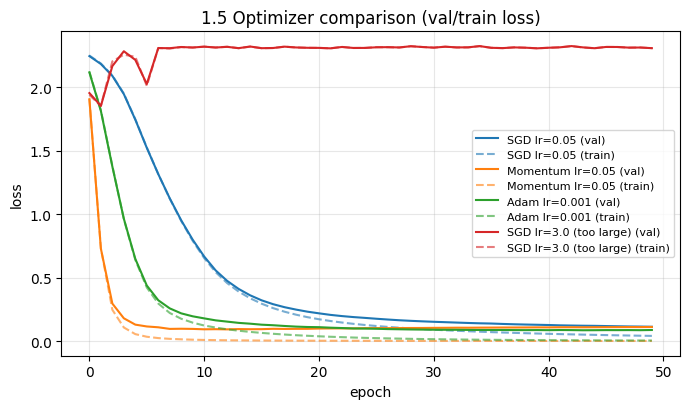

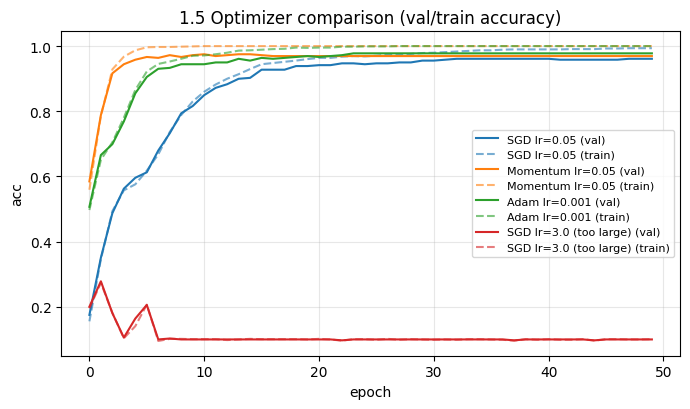

optimizer            ep1 val_loss  final train_loss  final val_acc  best val_acc  first ep >= 90%
-------------------------------------------------------------------------------------------------
SGD lr=0.05                2.2446            0.0409         0.9610        0.9610               15
Momentum lr=0.05           1.9045            0.0008         0.9694        0.9749                3
Adam lr=0.001              2.1168            0.0044         0.9777        0.9777                6
SGD lr=3.0 (too large)       1.9534            2.3070         0.1003        0.2786             None


In [28]:
# ── 1.5 Optimizer 비교 ─────────────────────────────────────────
opt_configs = [
    # (이름,               opt_name,     learning rate)
    ("SGD lr=0.05",        "sgd",        0.05),
    ("Momentum lr=0.05",   "momentum",   0.05),
    ("Adam lr=0.001",      "adam",       1e-3),
    ("SGD lr=3.0 (too large)",  "sgd",        3.0),
]

hist15 = {}
for name, opt_name, lr in opt_configs:
    # TODO: 모든 조건에서 동일한 구조 (64, 32) 의 모델을 새로 만들어라
    #       (같은 모델 객체를 재사용하면 앞 실험의 학습 결과가 남아 비교가 무의미해진다!)
    m = build_mlp(hidden=(64, 32))
    # TODO: opt_name 과 lr 을 전달해 50 epoch 학습
    hist15[name] = train_model(m, epochs=50, opt_name=opt_name, lr=lr)

plot_curves(hist15, "1.5 Optimizer comparison (val/train loss)", metric="loss")
plot_curves(hist15, "1.5 Optimizer comparison (val/train accuracy)", metric="acc")

# 수렴 속도: val accuracy 가 처음으로 90% 를 넘은 epoch
print(f"{'optimizer':<20}{'ep1 val_loss':>13}{'final train_loss':>18}"
      f"{'final val_acc':>15}{'best val_acc':>14}{'first ep >= 90%':>17}")
print("-" * 97)
for name, h in hist15.items():
    # TODO: val_acc 가 처음으로 0.90 이상이 되는 epoch 번호를 찾아라 (없으면 None)
    first90 = next((i + 1 for i, v in enumerate(h["val_acc"]) if v >= 0.90), None)
    print(f"{name:<20}{h['val_loss'][0]:>13.4f}{h['train_loss'][-1]:>18.4f}"
          f"{h['val_acc'][-1]:>15.4f}{max(h['val_acc']):>14.4f}{str(first90):>17}")

**해석 질문 1.5 (본인 출력값 인용)**

1. **SGD / Momentum / Adam이 val accuracy 90%에 도달한 epoch**를 각각 적으세요. Momentum이 순수 SGD보다 빠른 이유를, 강의 p.48의 "**방향이 자주 바뀌는 움직임은 줄이고, 계속 같은 방향으로 이동할 때는 속도를 높인다**"로 설명하세요.

Validation accuracy가 처음으로 90% 이상이 된 시점은 SGD가 15 epoch, 모멘텀이 3 epoch, Adam이 6 epoch이다. 따라서 모멘텀이 가장 빠르게 90%에 도달했고 Adam과 SGD가 그 뒤를 이었다. 모멘텀은 이전 gradient의 이동 방향을 일정 부분 유지한다. Gradient의 방향이 자주 바뀌는 구간에서는 불필요한 진동을 줄이고, 계속 같은 방향으로 이동하는 구간에서는 이전 이동량이 누적되어 더 빠르게 이동한다. 따라서 순수 SGD보다 빠르게 수렴할 수 있다.

2. **최종 val accuracy**는 셋이 얼마나 차이 났나요? "수렴이 빠르다"와 "최종 성능이 좋다"가 같은 말인지 본인 숫자로 판단하세요.

최종 validation accuracy는 SGD가 0.9610, 모멘텀이 0.9694, Adam이 0.9777이었다. Adam은 SGD보다 0.0167 즉 1.67%p 높았고, 모멘텀보다 0.0083 즉 0.83%p 높았다. 모멘텀은 SGD보다 0.0084 즉 0.84%p 높았다. 모멘텀이 90% 정확도에는 가장 먼저 도달했지만 최종 성능은 Adam이 가장 높았다. 따라서 수렴이 빠르다는 것은 목표 정확도에 빨리 도달한다는 의미이고, 최종 성능이 좋다는 것은 학습이 끝났을 때 더 높은 정확도를 얻는다는 의미이므로 두 표현은 같은 뜻이 아니다.

3. **`SGD lr=3.0`** 에서 무슨 일이 일어났나요? `val_loss` 값을 적고, 그 값이 $\ln(10) \approx 2.303$ 에 가까운 것이 무엇을 의미하는지 생각해 보세요. (힌트: 10개 클래스에 균등 확률을 주는 모델의 cross entropy는 얼마일까요?)

`SGD lr=3.0`에서는 validation loss가 약 2.30에서 감소하지 않았고 최종 validation accuracy도 0.1003에 이다. 10개 클래스에 동일한 확률을 부여하는 모델의 Cross Entropy Loss는 $$\log(10)$$ 이다. validation loss가 $\log(10)$에 가깝다는 것은 모델이 각 클래스에 거의 동일한 확률을 주고 있다는 것이다. Learning rate가 너무 커서 최적점을 지나치며 파라미터가 불안정하게 갱신되었기 때문이다.

4. 강의 객관식 퀴즈의 보기 ①과 ⑥은 **틀린 설명**입니다. 각각 어디가 틀렸는지 고쳐 쓰세요.
   - ① "미니배치 SGD는 full-batch GD에 비해 한 epoch당 파라미터 업데이트 횟수가 줄어드는 대신, 각 업데이트에서 계산되는 gradient 추정치가 더 정확하다."
   - ⑥ "RMSProp의 decay rate $\rho$를 0에 가깝게 설정할수록 과거 gradient의 영향이 오래 유지되어 AdaGrad와 유사하게 동작한다."

   ①에서 틀린 부분은 미니배치에서 계산한 gradient 추정치가 더 정확하다는 부분이다. 미니배치 SGD는 일부 데이터만 사용하므로 full-batch GD보다 gradient 추정치의 분산이 크고 더 불안정하다.
   ⑥에서는 decay rate $\rho$를 0에 가깝게 설정할수록 과거 gradient의 영향이 오래 유지된다는 부분이 틀렸다. RMSProp에서 $\rho$가 1에 가까울수록 과거의 제곱 gradient가 오래 유지되고, 0에 가까울수록 현재 gradient의 영향이 커진다.

5. Adam은 **Momentum(방향) + RMSProp(크기)** 라고 배웠습니다. 위 실험에서 Adam이 SGD보다 훨씬 작은 학습률(0.001 vs 0.05)을 쓰고도 더 빨리 수렴한 이유를, "파라미터마다 학습률을 다르게 준다"는 성질과 연결해 설명하세요.

Adam은 Momentum처럼 gradient의 이동 방향을 누적하고 RMSProp처럼 gradient 크기의 이동평균을 이용하여 파라미터마다 실제 업데이트 크기를 조절한다. Gradient가 큰 파라미터에는 상대적으로 작은 학습률을 적용하고 gradient가 작은 파라미터에는 상대적으로 큰 학습률을 적용한다. 그래서 Adam은 전체 learning rate가 0.001로 SGD의 0.05보다 작더라도 각 파라미터에 적절한 크기의 업데이트를 적용할 수 있다. 그 결과 SGD는 validation accuracy 90%에 15 epoch가 필요했지만 Adam은 6 epoch 만에 도달했고 최종 validation accuracy도 Adam이 0.9777로 SGD의 0.9610보다 높게 나타났다.

---

# 2. 심화 과제 — 스스로 생각하기

여기까지는 "돌리면 나오는" 영역이었습니다. 진짜 실력은 **그 값을 어떻게 읽고 판단하느냐**에서 갈립니다.
아래 세 문제는 모두 **강의 슬라이드가 주장한 것을 본인 실험으로 검증하거나 반증**하는 구조입니다. 슬라이드와 다른 결과가 나오면 **그대로 쓰고 원인을 추론**하세요.

---

### 2-A. 활성화 함수를 없애면? — "층을 쌓아도 선형"임을 직접 증명

강의 p.21은 이렇게 묻고 답했습니다.

> **Q. Why neural networks use Activation Functions?**
> **A. To introduce non-linearities into the network**

강의에서 수식으로 설명한 주장을 이제 **실험으로 확인**합니다. 활성화 함수 자리에 `nn.Identity()`(아무것도 안 하는 층)를 넣어 **은닉층이 2개인데도 사실은 선형 모델**인 네트워크를 만들고, 세 가지를 비교합니다.

| 모델 | 구조 | 파라미터 수 |
|---|---|---|
| **linear-deep** | 64 → 64 → 32 → 10, 활성화 **없음** | 6,570 |
| **single Linear** | 64 → 10, 은닉층 자체가 없음 | 650 |
| **ReLU MLP** (§1.2) | 64 → 64 → 32 → 10, ReLU | 6,570 |

그리고 **결정적 증거**로, linear-deep의 가중치 행렬 세 개를 곱해 **하나의 $10\times64$ 행렬로 접은 뒤**, 그 단일 선형변환이 원래 네트워크와 **똑같은 출력**을 내는지 확인합니다.

$$
W_{\text{eq}} = W^{(3)}W^{(2)}W^{(1)}, \qquad
b_{\text{eq}} = W^{(3)}\big(W^{(2)}b^{(1)} + b^{(2)}\big) + b^{(3)}
$$

In [29]:
# ── 2-A. 활성화 함수를 없애면 정말 선형 모델인가? ────────────────

# (1) 세 모델 학습 (조건 동일: Adam, 60 epoch)
# TODO: 활성화 함수 자리에 '아무 일도 하지 않는' 층을 넣어라 (힌트: nn.Identity)
lin_deep = build_mlp(hidden=(64, 32), act=nn.Identity)
single   = build_mlp(hidden=(),       act=nn.Identity)   # 은닉층 없음 = 그냥 Linear(64 -> 10)
relu_mlp = build_mlp(hidden=(64, 32), act=nn.ReLU)

h_lin  = train_model(lin_deep, epochs=60)
h_sing = train_model(single,   epochs=60)
h_relu = train_model(relu_mlp, epochs=60)

print(f"{'model':<26}{'params':>8}{'test_acc':>10}")
print("-" * 44)
for tag, m in [("linear-deep (64,32)", lin_deep),
               ("single Linear(64->10)", single),
               ("ReLU MLP (64,32)", relu_mlp)]:
    # TODO: test 세트에서 정확도를 구해 출력하라
    _, acc = evaluate(m, Xte, yte)
    print(f"{tag:<26}{count_params(m):>8}{acc:>10.4f}")

# (2) 결정적 증거: 가중치 세 개를 곱해 '하나의 선형변환'으로 접어 본다
Ws = [layer.weight.detach() for layer in lin_deep if isinstance(layer, nn.Linear)]
Bs = [layer.bias.detach()   for layer in lin_deep if isinstance(layer, nn.Linear)]

# TODO: W_eq = W3 @ W2 @ W1  (Ws[0]=W1, Ws[1]=W2, Ws[2]=W3)
W_eq = Ws[2] @ Ws[1] @ Ws[0]
b_eq = Ws[2] @ (Ws[1] @ Bs[0] + Bs[1]) + Bs[2]
print(f"\n접은 뒤 W_eq shape = {tuple(W_eq.shape)}  (원래 3개 행렬: "
      f"{tuple(Ws[0].shape)}, {tuple(Ws[1].shape)}, {tuple(Ws[2].shape)})")

with torch.no_grad():
    out_folded   = Xte @ W_eq.T + b_eq      # 접은 단일 선형변환의 출력
    out_original = lin_deep(Xte)            # 원래 3층 네트워크의 출력
    max_diff = (out_folded - out_original).abs().max().item()
print(f"두 출력의 최대 차이 = {max_diff:.3e}   <- 0에 가까우면 '완전히 같은 함수'라는 뜻")

# (3) ReLU 네트워크는 접을 수 있을까? (같은 방식으로 시도해 보고 결과를 관찰하라)
Ws_r = [layer.weight.detach() for layer in relu_mlp if isinstance(layer, nn.Linear)]
Bs_r = [layer.bias.detach()   for layer in relu_mlp if isinstance(layer, nn.Linear)]
W_eq_r = Ws_r[2] @ Ws_r[1] @ Ws_r[0]
b_eq_r = Ws_r[2] @ (Ws_r[1] @ Bs_r[0] + Bs_r[1]) + Bs_r[2]
with torch.no_grad():
    diff_r = (Xte @ W_eq_r.T + b_eq_r - relu_mlp(Xte)).abs().max().item()
print(f"[ReLU 네트워크에 같은 접기를 시도] 최대 차이 = {diff_r:.3e}")

model                       params  test_acc
--------------------------------------------
linear-deep (64,32)           6570    0.9472
single Linear(64->10)          650    0.9194
ReLU MLP (64,32)              6570    0.9722

접은 뒤 W_eq shape = (10, 64)  (원래 3개 행렬: (64, 64), (32, 64), (10, 32))
두 출력의 최대 차이 = 9.537e-06   <- 0에 가까우면 '완전히 같은 함수'라는 뜻
[ReLU 네트워크에 같은 접기를 시도] 최대 차이 = 4.759e+01


**Q2-A. (직접 돌려서 관찰 + 판단)**

**(1) 돌리기 전에 예측 먼저.** `linear-deep`(파라미터 6,570개)과 `single Linear`(650개) 중 어느 쪽 test accuracy가 높을지, **돌리기 전에** 한 줄로 적어 두세요. 파라미터가 10배 많으니 더 좋을까요?

실행 전에는 파라미터가 더 많은 linear-deep 모델의 정확도가 조금 더 높을 수 있지만, 활성화 함수가 없으므로 single Linear 모델과 표현력에는 큰 차이가 없을 것이라고 예상하였다. Linear 층을 여러 개 쌓아도 전체 연산은 하나의 Linear 층으로 합칠 수 있기 때문에 파라미터가 약 10배 많다고 해서 반드시 더 복잡한 함수를 학습하거나 더 높은 성능을 얻는 것은 아니다.

**(2) 본인 값 인용.** 세 모델의 test accuracy를 적으세요.
- linear-deep = 0.9472 / single Linear = 0.9194 / ReLU MLP = 0.9722

**(3) 결정적 증거 해석.** "두 출력의 최대 차이"는 얼마였나요? 이 값이 0이 아니라 $10^{-5}$ 정도인 이유는 무엇인가요? (힌트: `torch.float32`의 유효자릿수) 그리고 이 실험이 **왜 정확도 비교보다 강한 증거**인지 설명하세요. (정확도는 0.93 vs 0.92처럼 조금 다를 수 있지만, 이 실험은 무엇을 보여 주나요?)

linear-deep 모델을 하나의 선형변환으로 접었을 때 원래 모델 출력과 접은 모델 출력의 최대 차이는 $9.537\times10^{-6}$이었다. 이 값이 정확히 0이 아닌 이유는 `torch.float32`가 실수를 유한한 자릿수로 저장하며, 행렬곱의 계산 순서에 따라 작은 반올림 오차가 발생하기 때문이다. Accuracy가 비슷한 모델도 내부적으로는 서로 다른 함수를 표현할 수 있지만, 이 실험에서는 모든 test 입력에 대한 실제 출력값이 거의 완전히 같았다. 따라서 활성화 함수가 없는 여러 Linear 층은 하나의 Linear 층과 같은 함수를 나타낸다고 볼 수 있다.

**(4) 반대 실험.** ReLU 네트워크에 같은 접기를 시도했을 때 차이는 얼마였나요? 왜 ReLU는 접히지 않는지, "$\max(0, z)$ 는 행렬곱으로 표현할 수 없다"는 사실과 연결해 설명하세요.

ReLU 네트워크에 같은 방식의 접기를 적용했을 때 최대 차이는 $4.759\times10^1$, 즉 약 47.59였다. 따라서 접은 선형변환과 원래 ReLU 네트워크의 출력은 서로 크게 달랐다.

**(5) 본인 언어로.** 위 결과를 종합해, 강의 p.21의 **"To introduce non-linearities into the network"** 가 정확히 무슨 뜻인지 한 문단으로 쓰세요. "활성화 함수가 없으면 층을 100개 쌓아도 ____ 와 같다"는 문장을 반드시 포함하세요.

Linear 층 사이에 활성화 함수를 넣어 모델이 단순한 선형 관계를 넘어 복잡한 패턴과 비선형 결정 경계를 학습할 수 있게 한다는 의미이다. 활성화 함수가 없으면 층을 100개 쌓아도 하나의 Linear 층과 같다. 여러 Linear 층을 연속으로 계산해도 결국 하나의 행렬곱과 bias로 합칠 수 있기 때문이다. 따라서 층을 깊게 쌓는 것만으로는 모델의 표현력이 커지지 않으며, ReLU와 같은 활성화 함수가 들어가야 깊은 신경망이 복잡한 함수를 학습할 수 있다.

---

### 2-B. Go Wider or Deeper? — 파라미터 수를 맞춰 놓고 공정하게 붙이기

강의 p.36은 이렇게 결론지었습니다.

> 모델 용량을 단순히 폭으로 늘리는 것보다(Wide), 적절한 구조를 가진 깊은 네트워크(Deep)가
> **파라미터를 더 효율적으로 사용해 높은 성능**을 낼 수 있다.

이 주장을 **공정하게** 검증하려면 두 모델의 **파라미터 수를 비슷하게 맞춰야** 합니다. 파라미터가 많은 쪽이 이기면 그건 구조의 승리가 아니라 용량의 승리니까요.

**설계**
- **Wide**: `64 → H → 10` (은닉층 1개) → 파라미터 수 $= 75H + 10$
- **Deep**: `64 → h → h → h → h → 10` (은닉층 4개) → 파라미터 수 $= 3h^2 + 78h + 10$

$H = 256$ 이면 19,210개. 이와 **10% 이내**로 맞는 $h$를 직접 찾아 넣으세요.

> ⚠️ **결과가 강의 슬라이드와 다르게 나올 수 있습니다.** 그래도 그대로 보고하고 원인을 추론하세요. 시드 하나로 결론 내리지 말고 **여러 시드에서 반복**해 보는 것이 이 절의 진짜 과제입니다.

Wide 64-256-10 파라미터 수 = 19210
Deep 64-68x4-10 파라미터 수 = 19186
파라미터 수 차이 = 0.12%  -> 10% 이내여야 공정한 비교
Wide (1 x 256)   final val_acc = 0.9833 | best val_acc = 0.9861 | test_acc = 0.9778 | final train_loss = 0.0029
Deep (4 x 68)    final val_acc = 0.9666 | best val_acc = 0.9749 | test_acc = 0.9722 | final train_loss = 0.0003


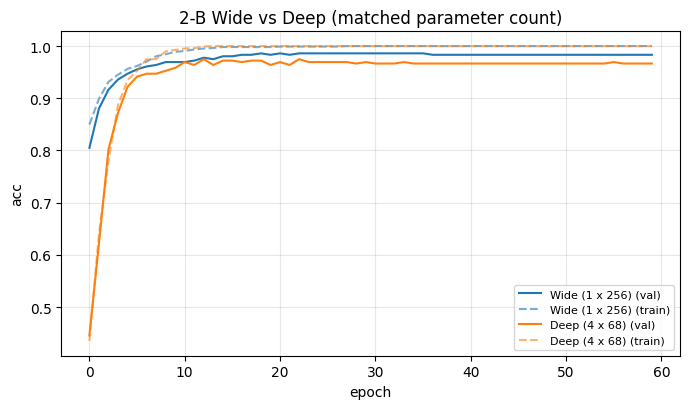


[여러 시드에서 반복]
  seed=0      wide=0.9778  deep=0.9667
  seed=1      wide=0.9750  deep=0.9750
  seed=42     wide=0.9778  deep=0.9694
  seed=8664   wide=0.9778  deep=0.9722
  seed=7777   wide=0.9833  deep=0.9778

Wide 평균 = 0.9783 (표준편차 0.0027)
Deep 평균 = 0.9722 (표준편차 0.0039)
Wide 가 이긴 횟수: 4 / 5


In [31]:
# ── 2-B. Wide vs Deep (파라미터 수를 맞춘 공정 비교) ─────────────

# (1) 파라미터 수 맞추기 — Deep 쪽 h 를 직접 찾으세요
H = 256
wide = build_mlp(hidden=(H,))
print(f"Wide 64-{H}-10 파라미터 수 = {count_params(wide)}")

# TODO: 은닉층 4개짜리 Deep 모델의 폭 h 를 정하라.
#       3h^2 + 78h + 10 이 위 숫자와 10% 이내가 되도록. (h 를 몇 개 넣어 보며 찾아도 좋다)
h = 68
deep = build_mlp(hidden=(h, h, h, h))
print(f"Deep 64-{h}x4-10 파라미터 수 = {count_params(deep)}")

diff_pct = abs(count_params(wide) - count_params(deep)) / count_params(wide) * 100
print(f"파라미터 수 차이 = {diff_pct:.2f}%  -> 10% 이내여야 공정한 비교")
assert diff_pct < 10, "파라미터 수가 10% 넘게 차이납니다. h 를 다시 고르세요."

# (2) 동일 조건으로 학습 후 비교
hist2b = {}
for tag, m in [(f"Wide (1 x {H})", wide), (f"Deep (4 x {h})", deep)]:
    hist2b[tag] = train_model(m, epochs=60)
    _, te_acc = evaluate(m, Xte, yte)
    print(f"{tag:<16} final val_acc = {hist2b[tag]['val_acc'][-1]:.4f} | "
          f"best val_acc = {max(hist2b[tag]['val_acc']):.4f} | test_acc = {te_acc:.4f} | "
          f"final train_loss = {hist2b[tag]['train_loss'][-1]:.4f}")

plot_curves(hist2b, "2-B Wide vs Deep (matched parameter count)", metric="acc")

# (3) 시드 하나로 결론 내지 않기 — 5개 시드에서 반복
print("\n[여러 시드에서 반복]")
wide_scores, deep_scores = [], []
for s in [0, 1, 42, MY_SEED, 7777]:
    w = build_mlp(hidden=(H,), seed=s)
    d = build_mlp(hidden=(h, h, h, h), seed=s)
    train_model(w, epochs=60, seed=s)
    train_model(d, epochs=60, seed=s)
    # TODO: 각 모델의 test accuracy 를 리스트에 담아라
    wide_scores.append(evaluate(w, Xte, yte)[1])
    deep_scores.append(evaluate(d, Xte, yte)[1])
    print(f"  seed={s:<6} wide={wide_scores[-1]:.4f}  deep={deep_scores[-1]:.4f}")

print(f"\nWide 평균 = {np.mean(wide_scores):.4f} (표준편차 {np.std(wide_scores):.4f})")
print(f"Deep 평균 = {np.mean(deep_scores):.4f} (표준편차 {np.std(deep_scores):.4f})")
print(f"Wide 가 이긴 횟수: {sum(w > d for w, d in zip(wide_scores, deep_scores))} / 5")

**Q2-B. (본인 출력값 인용 + 판단)**

**(1) 파라미터 맞추기.** 본인이 고른 `h`는 얼마이고 Deep의 파라미터 수는 몇 개인가요? Wide와 몇 % 차이인가요? **왜 파라미터 수를 맞춰야 공정한 비교**가 되는지 한 문장으로 쓰세요.

Deep 모델의 폭은 $h=68$로 설정하였다. Wide 모델의 파라미터 수는 19210개이고 Deep 모델의 파라미터 수는 19186개이며 차이는 0.12%이다. 파라미터 수를 비슷하게 맞춰야 모델의 깊이 외에 전체 모델 용량이 결과에 미치는 영향을 통제할 수 있으므로 공정한 비교가 된다.

**(2) 단일 시드 결과.** Wide와 Deep의 test accuracy를 적으세요. 강의 p.36의 결론("Deep이 파라미터를 더 효율적으로 사용해 높은 성능")이 **본인 실험에서 재현되었나요?**

단일 seed 실험에서 Wide 모델의 test accuracy는 0.9778이고 Deep 모델은 0.9722였다. Wide 모델이 Deep 모델보다 0.0056 즉 0.56%p 높은 성능을 보였다. 따라서 Deep 모델이 같은 수의 파라미터를 더 효율적으로 사용하여 높은 성능을 낸다는 강의의 결론은 이번 단일 실험에서는 재현되지 않았다.

**(3) 5개 시드 결과.** Wide/Deep의 평균과 표준편차, 그리고 Wide가 이긴 횟수를 적으세요. 만약 (2)의 결론이 5개 시드에서도 유지된다면 **"시드 운"이 아니라는 근거**가 됩니다. 유지되었나요?

5개 seed에서 Wide 모델의 평균 test accuracy는 0.9783이고 표준편차는 0.0027이었다. Deep 모델의 평균 test accuracy는 0.9722이고 표준편차는 0.0039였다. Wide 모델은 5번 중 4번 Deep 모델보다 높은 정확도를 보였고 나머지 1번은 같은 정확도를 보였다. 따라서 Wide 모델이 더 좋은 결과는 특정 seed 하나에서만 우연히 발생한 현상이라고 보기 어렵다.

**(4) 원인 추론 — 여기가 핵심입니다.** 결과가 강의와 달랐다면, 그 원인으로 다음 중 무엇을 의심하겠습니까? 최소 두 가지를 고르고 본인 데이터의 구체적 숫자로 근거를 대세요.
- (a) 데이터가 너무 작다 (훈련 샘플 몇 개인지 적을 것)
- (b) 입력이 8×8 = 64차원으로 단순해 계층적 특징이 필요 없다
- (c) Deep 쪽이 아직 수렴하지 않았다 (양쪽 `final train_loss`를 비교해 판단할 것)
- (d) 4층 정도로는 "Deep"이라 하기 부족하다
- (e) 규제·학습률을 Deep에 맞게 따로 튜닝하지 않았다

(a) 데이터가 너무 작다.
이번 실험의 전체 train 데이터는 1078개뿐이다. 파라미터가 19186개인 Deep 모델을 학습하기에는 샘플 수가 적기 때문에, 깊은 구조의 표현력을 충분히 활용하기보다 훈련 데이터에 맞춰질 가능성이 있다. 실제로 Deep 모델의 final train loss는 0.0003까지 감소했지만 test accuracy는 0.9722로 Wide 모델의 0.9778보다 낮았다.

(b) 입력이 단순해 계층적인 특징이 크게 필요하지 않다.
입력은 $8\times8=64$차원의 작은 손글씨 이미지이다. 고해상도 이미지처럼 경계, 질감, 부분 형태, 전체 물체를 여러 단계로 학습해야 하는 문제가 아니므로 4개의 은닉층이 주는 계층적 표현의 장점이 크지 않을 수 있다. 5개 seed에서도 Wide 모델의 평균 test accuracy는 0.9783이고 Deep 모델은 0.9722로, 단순한 Wide 모델이 더 높은 성능을 보였다.


**(5) 조건을 붙여 다시 쓰기.** 강의 p.36의 문장을 **본인 실험 결과와 모순되지 않게** 조건을 붙여 고쳐 쓰세요. (예: "____ 한 조건에서는 Deep이 ____ 하다.") 그리고 실제로 Deep이 압도적으로 유리한 대표 사례를 강의 5장(Expansion into Modern AI)에서 하나 골라, **왜 그 도메인에서는 다른지** 한 문장으로 설명하세요.

충분한 데이터와 적절한 최적화가 있고 계층적 특징 학습이 필요한 문제에서는 Deep 모델이 파라미터를 더 효율적으로 사용해 높은 성능을 낼 수 있다. 이번 데이터는 훈련 샘플이 1078개이고 입력이 $8\times8$로 단순하여 Wide 모델의 평균 정확도 0.9783이 Deep 모델의 0.9722보다 높았다. 반면 ResNet은 복잡한 자연 이미지의 특징을 여러 단계로 학습하고 residual connection으로 깊은 모델의 학습을 안정화하므로 Deep 구조가 유리하다.

---

### 2-C. 나만의 최고 모델 만들기 (유형 C 맛보기)

지금까지의 실험에서 배운 것을 **하나의 모델에 종합**합니다.

**규칙**
1. **데이터 분할은 고정** — `Xtr / Xva / Xte`를 그대로 쓰세요. (새로 나누면 비교가 무의미해집니다.)
2. **test는 마지막에 딱 한 번만.** 모든 튜닝 결정은 **val**로 하세요. test를 보고 하이퍼파라미터를 고르면 그건 test가 아니라 두 번째 val입니다.
3. **방법은 자유** — 층 수·폭·활성화 함수·Dropout·L2·학습률·optimizer·batch size·epoch 수·Early Stopping 등 무엇이든.
4. **실험 기록 필수** — 시도한 조건과 val 성능을 아래 `log` 리스트에 **모두** 남기세요. 실패한 실험도 포함합니다.

**평가는 최종 정확도만 보지 않습니다.** *어떤 가설을 세워 무엇을 바꿨고, 결과가 그 가설을 지지했는지* 를 함께 봅니다.

> 💡 **출발점 힌트:** §1.2 baseline은 test 0.9667이었습니다. §1.4에서 L2가 효과적이었고, §1.5에서 Adam/Momentum이 빨랐으며, §2-B에서 이 데이터에는 Wide가 유리했습니다. 여기에 Early Stopping(val_loss 최저 시점의 가중치를 저장해 두었다가 복원)을 더하면 어떨까요?

In [34]:
# ── 2-C. 나만의 최고 모델 ──────────────────────────────────────
# 규칙: 튜닝 판단은 반드시 val 로! test 는 맨 마지막 한 번만.

log = []   # (설명, 하이퍼파라미터, best_val_acc) 를 모두 기록 — 실패한 실험도 남길 것

def try_config(desc, hidden, act=nn.ReLU, p_drop=0.0, wd=0.0,
               opt_name="adam", lr=1e-3, epochs=80, batch_size=64):
    """조건 하나를 학습하고 val 성능을 기록한다. (test 는 건드리지 않는다)"""
    m = build_mlp(hidden=hidden, act=act, p_drop=p_drop)
    h = train_model(m, epochs=epochs, opt_name=opt_name, lr=lr,
                    weight_decay=wd, batch_size=batch_size)
    best_val = max(h["val_acc"])
    best_ep  = int(np.argmin(h["val_loss"])) + 1
    log.append((desc, best_val, best_ep, count_params(m)))
    print(f"{desc:<38} best_val_acc={best_val:.4f}  (val_loss 최저 ep={best_ep}, params={count_params(m)})")
    return m, h

# ── 예시로 두 개만 돌려 둡니다. 아래에 본인 실험을 최소 4개 이상 추가하세요. ──
try_config("A. baseline 재현 (64,32)", hidden=(64, 32))
try_config("B. Wide + 약한 L2", hidden=(256,), wd=1e-4)

# TODO: 본인 실험을 최소 4개 추가하세요. 아무거나 찍지 말고 '가설 -> 검증' 형태로.
#   예) 가설: §1.4처럼 L2 가 도움이 된다면 wd 를 키울수록 val 이 좋아질 것이다
#       try_config("C. Wide + wd=1e-3", hidden=(256,), wd=1e-3)
#   예) 가설: §2-B 에서 Wide 가 유리했으니 더 넓히면 더 좋아질 것이다
#       try_config("D. 더 넓게 (512,)", hidden=(512,))


# 가설: 앞선 실험에서 L2가 도움이 되었으므로 wd를 1e-3으로 높이면 val 성능이 좋아질 것이다.
try_config("C. Wide + wd=1e-3", hidden=(256,), wd=1e-3)

# 가설: Wide 모델이 Deep 모델보다 좋았으므로 폭을 512로 늘리면 val 성능이 좋아질 것이다.
try_config("D. 더 넓게 (512,)", hidden=(512,))

# 가설: Dropout을 적용하면 과적합이 줄어들어 val 성능이 좋아질 것이다.
try_config("E. Wide + Dropout", hidden=(256,), p_drop=0.2, wd=1e-4)

# 가설: 은닉층을 두 개 사용하면 특징을 단계적으로 학습하여 한 층짜리 Wide 모델보다 val 성능이 좋아질 것이다.
try_config("F. 2층 + 약한 L2", hidden=(128, 64), wd=1e-4)


# ── 최종 선택 & 단 한 번의 test 평가 ──────────────────────────
print("\n" + "=" * 70)
print(f"{'실험':<40}{'best_val_acc':>14}{'best_ep':>9}{'params':>8}")
print("-" * 70)
for desc, bv, be, npar in sorted(log, key=lambda r: -r[1]):
    print(f"{desc:<40}{bv:>14.4f}{be:>9}{npar:>8}")

# TODO: 위 표에서 val 성능이 가장 좋았던 조건을 골라 아래에 그대로 다시 설정하라
FINAL_HIDDEN  = (128, 64)
FINAL_DROPOUT = 0.0
FINAL_WD      = 1e-4
FINAL_OPT     = "adam"
FINAL_LR      = 1e-3
FINAL_EPOCHS  = 35

final_model = build_mlp(hidden=FINAL_HIDDEN, p_drop=FINAL_DROPOUT)
final_hist  = train_model(final_model, epochs=FINAL_EPOCHS, opt_name=FINAL_OPT,
                          lr=FINAL_LR, weight_decay=FINAL_WD)

final_test_loss, final_test_acc = evaluate(final_model, Xte, yte)
print("\n" + "=" * 70)
print(f"[최종 모델] val 최고 = {max(final_hist['val_acc']):.4f}")
print(f"[최종 모델] TEST accuracy = {final_test_acc:.4f}  (baseline 대비 "
      f"{final_test_acc - test_acc:+.4f})")
print("=" * 70)

A. baseline 재현 (64,32)                 best_val_acc=0.9777  (val_loss 최저 ep=44, params=6570)
B. Wide + 약한 L2                        best_val_acc=0.9861  (val_loss 최저 ep=71, params=19210)
C. Wide + wd=1e-3                      best_val_acc=0.9861  (val_loss 최저 ep=71, params=19210)
D. 더 넓게 (512,)                         best_val_acc=0.9861  (val_loss 최저 ep=44, params=38410)
E. Wide + Dropout                      best_val_acc=0.9861  (val_loss 최저 ep=73, params=19210)
F. 2층 + 약한 L2                          best_val_acc=0.9861  (val_loss 최저 ep=35, params=17226)

실험                                        best_val_acc  best_ep  params
----------------------------------------------------------------------
B. Wide + 약한 L2                                 0.9861       71   19210
C. Wide + wd=1e-3                               0.9861       71   19210
D. 더 넓게 (512,)                                  0.9861       44   38410
E. Wide + Dropout                               0.9861       73   19210
F. 2층

**Q2-C. 전략 보고서 (텍스트로 서술)**

**(1) 실험 로그.** 위 표를 그대로 옮기고, **실패한 실험도 포함**해 최소 6개를 보고하세요.






| 실험 | best val accuracy | best epoch | 파라미터 수 |
|---|---:|---:|---:|
| A. baseline 재현 (64, 32) | 0.9777 | 44 | 6570 |
| B. Wide + 약한 L2 | 0.9861 | 71 | 19210 |
| C. Wide + wd=1e-3 | 0.9861 | 71 | 19210 |
| D. 더 넓게 (512,) | 0.9861 | 44 | 38410 |
| E. Wide + Dropout | 0.9861 | 73 | 19210 |
| F. 2층 + 약한 L2 | 0.9861 | 35 | 17226 |

A는 다른 실험보다 validation accuracy가 낮았으며, C부터 F까지는 구조나 규제를 변경했지만 B보다 성능이 향상되지는 않았다. 성능이 좋아지지 않은 실험도 제외하지 않고 모두 기록하였다.


**(2) 가설 → 검증.** 시도한 것 중 **가설이 맞았던 것 하나**와 **가설이 틀렸던 것 하나**를 골라, 각각 이렇게 정리하세요.
- 가설: "____ 하면 ____ 할 것이다. 왜냐하면 §__ 에서 ____ 를 봤기 때문이다."
- 결과: val accuracy ____ → ____
- 판정 및 해석: ____

[가설이 맞았던 실험]
- 가설: §2-B에서 Wide 모델이 Deep 모델보다 좋은 결과를 보였으므로, 모델을 Wide 구조로 변경하고 약한 L2 규제를 적용하면 baseline보다 validation 성능이 좋아질 것이다.
- 결과: Validation accuracy가 0.9777에서 0.9861로 증가하였다.
- 판정 및 해석: 가설과 일치하였다. Wide 구조가 이 데이터에 적합했고 약한 L2 규제가 일반화에 도움을 준 것으로 볼 수 있다.

[가설이 틀렸던 실험]
- 가설: Wide 모델의 폭을 256에서 512로 늘리면 더 많은 특징을 학습하여 validation 성능이 좋아질 것이다.
- 결과: Validation accuracy는 0.9861에서 0.9861로 변하지 않았다.
- 판정 및 해석: 가설과 일치하지 않았다. 입력이 $8\times8=64$차원으로 단순하여 폭을 더 늘려도 추가적인 성능 향상이 없었고 파라미터 수만 19210개에서 38410개로 증가하였다.


**(3) 최종 선택의 근거.** 왜 그 조건을 최종 모델로 골랐나요? **val 기준으로** 설명하세요.

B부터 F까지의 best validation accuracy는 모두 0.9861로 같았다. 그중 F는 파라미터 수가 17226개로 가장 적고 validation loss가 가장 낮았던 시점도 35 epoch로 가장 빨랐다. 따라서 같은 validation 성능을 더 적은 파라미터와 짧은 학습으로 달성한 F의 `(128, 64) + L2 wd=1e-4` 조건을 최종 모델로 선택하였다.

**(4) val과 test의 간극.** 최종 모델의 best val accuracy와 test accuracy를 나란히 적으세요. 어느 쪽이 높나요? val이 test보다 높다면 그 이유는 무엇일까요? (힌트: val은 이미 **선택에 사용된** 데이터입니다.)

최종 모델의 best validation accuracy는 0.9861이고 test accuracy는 0.9833이었다. Test accuracy가 validation accuracy보다 0.0028 즉 0.28%p 낮았다. Validation 데이터는 여러 모델과 하이퍼파라미터를 비교하고 최종 조건을 선택하는 데 반복적으로 사용되었으므로 validation 성능에 어느 정도 맞춰졌을 수 있다. 반면 test 데이터는 모델 선택에 사용하지 않고 마지막에 한 번만 평가했기 때문에 새로운 데이터에 대한 일반화 성능을 더 공정하게 보여준다.

**(5) 정직하게.** 만약 test를 여러 번 보면서 튜닝했다면, 그 test accuracy는 왜 **실제 성능의 과대평가**인가요? 이것이 §1.1에서 배운 데이터 누수와 어떻게 같은 문제인지 설명하세요.
만약 test 결과를 여러 번 확인하면서 모델 구조나 하이퍼파라미터를 수정했다면 test 데이터가 간접적으로 모델 선택에 사용된 것이다. 이 경우 test accuracy는 실제 새로운 데이터에 대한 성능보다 높게 나타날 수 있으므로 실제 성능의 과대평가가 된다. 이것은 test 데이터의 정보를 전처리나 학습 과정에서 미리 사용하는 데이터 누수와 같은 문제이다. Test 데이터는 모든 모델 선택이 끝난 뒤 마지막에 한 번만 사용해야 독립적인 최종 평가 데이터로서 의미를 유지할 수 있다.

## 3. 결론

`digits`(1,797장, 8×8) 위에서 **데이터 준비 → MLP 학습 → 세 가지 고질병 실험 → 구조 비교**를 진행했습니다. 각 항목을 **본인이 뽑은 값**을 근거로 정리하세요.

- **기본 MLP 학습 (§1.2):** 모델의 파라미터 수와 test accuracy는 얼마였나요? train/val loss 곡선에서 Early Stopping이 필요해 보인 시점과 그 근거는? → 기본 MLP의 파라미터 수는 6570개이고 test accuracy는 0.9722였다. Train loss는 마지막까지 0.0028로 감소했지만 validation loss는 44 epoch에서 0.0852로 가장 낮아진 뒤 마지막에 0.0879로 증가했으므로 44 epoch 부근에서 Early Stopping이 필요하다고 판단하였다.
- **Vanishing Gradient (§1.3):** Sigmoid 8층의 첫 층 gradient norm ____ vs 마지막 층 ____. 이 차이가 train accuracy ____로 이어진 인과를 한 문장으로: Sigmoid 8층 네트워크의 첫 번째 층 gradient norm은 $2.32\times10^{-7}$이고 마지막 층은 $2.68\times10^{-1}$이었다. 입력에 가까운 층의 gradient가 매우 작아 파라미터가 제대로 갱신되지 않았고, 그 결과 train accuracy가 0.2032에 머물렀다.
- **Overfitting (§1.4):** baseline의 gap(val_loss − train_loss) = ____, Early Stopping 시점 = epoch ____. 네 처방 중 본인 데이터에서 최선이었던 것과 그 이유: Baseline의 gap은 0.2994였고 Early Stopping 시점은 27 epoch였다. 네 조건 중에서는 `L2 wd=1e-2`가 가장 적절했다고 판단하였다. Best validation accuracy가 0.9331로 가장 높았고 마지막 validation loss도 0.2949로 가장 낮았으며, gap도 baseline의 0.2994에서 0.2639로 감소했기 때문이다.
- **Optimization (§1.5):** val 90% 도달 epoch — SGD ____ / Momentum ____ / Adam ____. "수렴 속도"와 "최종 성능"이 다른 이야기인 이유: Validation accuracy 90%에 처음 도달한 시점은 SGD가 15 epoch, Momentum이 3 epoch, Adam이 6 epoch였다. Momentum이 가장 빠르게 90%에 도달했지만 최종 validation accuracy는 Adam이 0.9777로 가장 높았다. 따라서 수렴 속도가 빠르다는 것은 일정 수준의 성능에 빨리 도달한다는 의미이고, 최종 성능이 좋다는 것은 학습이 끝났을 때 더 높은 정확도를 얻는다는 의미이므로 서로 다른 개념이다.
- **구조 (§2-A, §2-B):** 활성화 함수를 없앴을 때 접기 오차 ____가 증명한 것은? 파라미터를 맞춘 Wide vs Deep에서 이긴 쪽과, 그 결과가 강의 슬라이드와 달랐다면 그 조건은? 활성화 함수가 없는 3층 Linear 모델을 하나의 Linear 변환으로 접었을 때 두 출력의 최대 차이는 $9.537\times10^{-6}$이었다. 이 결과는 활성화 함수가 없으면 여러 Linear 층을 쌓아도 하나의 Linear 층과 같은 함수를 나타낸다는 것을 보여준다. 파라미터 수를 맞춘 Wide와 Deep 비교에서는 Wide 모델의 평균 test accuracy가 0.9783이고 Deep 모델은 0.9722였으며 Wide가 5번 중 4번 이겼다. 이는 훈련 샘플이 1078개로 적고 입력이 $8\times8$로 단순하여 계층적인 특징 학습의 필요성이 크지 않았기 때문이라고 판단하였다.
- **한 문장 요약:** 이번 과제에서 **강의 슬라이드의 일반론이 본인 데이터에서는 성립하지 않았던 사례**를 하나 고르고, 거기서 배운 교훈을 한 문장으로: 강의에서는 적절한 구조를 가진 Deep 모델이 파라미터를 효율적으로 사용해 높은 성능을 낼 수 있다고 설명했지만, 이번의 작고 단순한 digits 데이터에서는 Wide 모델의 평균 test accuracy가 0.9783으로 Deep 모델의 0.9722보다 높았으므로 Deep 구조의 장점은 데이터가 계층적 특징을 요구하고 학습 조건이 적절할 때 나타난다는 점을 배웠다.

## 4. 회고

겪은 어려움과 해결 과정을 3~5문장으로 적습니다. 끝까지 헷갈린 개념(gradient 누적, Dropout의 train/eval 차이, val과 test의 역할 구분, 규제 강도의 trade-off 등) 1~3개도 함께: 처음에는 `optimizer.zero_grad()`를 호출하지 않으면 이전 미니배치의 gradient가 계속 누적된다는 점이 헷갈렸는데, 직접 제거한 결과 validation loss가 0.0879에서 2.2888로 증가하는 것을 보고 필요성을 이해하였다. Dropout은 학습할 때만 일부 뉴런을 끄고 평가할 때는 전체 뉴런을 사용하므로 `model.train()`과 `model.eval()`을 구분해야 한다는 점도 실험을 통해 확인하였다. 또한 validation 데이터는 모델과 하이퍼파라미터를 선택하는 데 사용하고 test 데이터는 모든 선택이 끝난 뒤 마지막에 한 번만 사용해야 한다는 점을 익혔다. 규제는 강할수록 좋은 것이 아니라 너무 강한 L2를 적용하면 best validation accuracy가 0.7911까지 낮아지는 등 underfitting이 발생할 수 있다는 점도 확인하였다.

## 5. 생성형 AI 활용 (비판적 사용)

AI는 **검산기·설명 도우미**로 활용하고 최종 판단은 본인이 합니다.

* **어디에 썼나** (PyTorch 문법 디버깅·개념 설명·에러 해석 등 구체적으로): `train_test_split`에서 `stratify=y`를 잘못 사용해 샘플 수가 맞지 않았던 오류, Momentum optimizer에서 `weight_decay`를 중복 입력한 오류, 학습 루프에서 순전파 코드가 빠진 오류를 찾는 데 사용하였다. 또한 `optimizer.zero_grad()`, `loss.backward()`, `optimizer.step()`의 실행 순서와 gradient 누적 원리, `CrossEntropyLoss`와 Softmax의 관계, Dropout과 L2 규제의 차이를 이해하는 데 활용하였다. 실험 결과가 나온 뒤에는 출력값을 이용해 overfitting, vanishing gradient, Wide와 Deep 모델의 차이를 해석하는 과정에서 설명 도우미로 사용하였다.

* **AI가 이 실험에는 틀린 답을 준 사례** — 예를 들면 다음과 같은 오류가 자주 나옵니다.

  * 모델 마지막에 `nn.Softmax`를 붙이는 코드 (`CrossEntropyLoss`와 중복)
  * "학습률이 크면 항상 발산한다"고 조건 없이 단정
  * "Dropout을 쓰면 성능이 좋아진다"고 단정 (§1.4 본인 결과와 비교)
  * "Deep이 Wide보다 낫다"고 단정 (§2-B 5개 시드 결과와 비교)
  * 존재하지 않는 인자·API 이름을 사용하거나, 앞 셀에서 정의한 변수명(`train_model`, `hist_base` 등)을 무시

  본인이 겪은 사례와, 그것을 **어떻게 알아채고 고쳤는지**(본인 출력값과 대조 / 공식 문서 확인 / 직접 실험) 적으세요: AI가 실험 결과를 표로 출력하는 코드에서 `pd.DataFrame()`을 제안하면서 `import pandas as pd`를 포함하지 않아 `NameError: name 'pd' is not defined`가 발생하였다. 오류 메시지에서 `pd`가 정의되지 않았다는 사실을 확인한 뒤 `import pandas as pd`를 추가하여 해결하였다. 또한 AI가 한 번은 Wide 모델의 구조 `(256,)`와 다른 실험의 best epoch인 35를 섞어 최종 설정으로 제안하였다. 실험 결과표를 다시 확인해 동일한 조건의 구조, Dropout, weight decay, optimizer, learning rate와 best epoch를 함께 사용하도록 수정하였다. 이 경험을 통해 AI가 제시한 코드를 그대로 사용하지 않고 실제 오류 메시지와 출력표를 직접 대조해야 한다는 점을 확인하였다.

* **실제 대화 내역** 붙여넣기:

```text

나:
ValueError: Found input variables with inconsistent numbers of samples: [719, 1797]

AI:
두 번째 분할에서 X_tmp와 y_tmp는 719개인데 stratify에 전체 y를 사용해서 발생한 오류이다. 두 번째 분할에서는 stratify=y_tmp를 사용해야 한다.

수정 코드:
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp,
    test_size=0.5,
    random_state=MY_SEED,
    stratify=y_tmp
)


나:
Momentum optimizer와 학습 루프를 작성했는데 틀린 부분이 있는지 확인좀

AI:
Momentum 부분에서 weight_decay가 두 번 들어갔고 momentum=0.9가 빠졌다. 또한 순전파 결과를 계산하는 out=model(xb)가 필요하다.

수정 코드:
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=lr,
    momentum=0.9,
    weight_decay=weight_decay
)

optimizer.zero_grad()
out = model(xb)
loss = criterion(out, yb)
loss.backward()
optimizer.step()

나:
(결과 사진)
optimizer.zero_grad()를 지우니까 일케도ㅓㅣㅁ
AI:
PyTorch의 backward()는 기존 gradient를 덮어쓰지 않고 누적한다. zero_grad()를 제거하면 이전 미니배치의 gradient까지 계속 더해져 파라미터가 지나치게 크게 갱신된다. 정상 학습에서는 test loss가 0.1051이고 accuracy가 0.9722였지만, 제거 후에는 test loss가 6.7994이고 accuracy가 0.9222로 나빠졌으므로 gradient 누적으로 학습이 불안정해진 것을 확인할 수 있다.


나:
모델 마지막에 nn.Softmax(dim=1)을 추가하고 기존 모델과 비교하려면 코드?

AI:
먼저 zero_grad()를 복구하고 기존 모델과 Softmax 모델을 같은 초기값과 조건으로 새로 학습해야 한다. CrossEntropyLoss는 logits를 입력으로 받아 내부에서 softmax에 해당하는 연산을 처리하므로 모델 마지막에 Softmax를 추가하면 중복 처리가 발생한다.

나:
(결과 사진)

AI:
Softmax 추가 모델의 accuracy는 0.83%p 감소했지만 loss는 크게 증가하였다. Accuracy는 가장 큰 출력의 위치만 비교하므로 차이가 작을 수 있지만, loss는 예측 확률과 확신도까지 반영하므로 중복 Softmax의 문제가 더 크게 나타난다.


나:
(결과 사진)

AI:
강의의 설명은 Deep이 항상 좋다는 뜻이 아니라, 충분한 데이터가 있고 계층적인 특징이 필요하며 깊은 모델에 적합한 구조와 최적화가 적용된 조건에서 파라미터를 효율적으로 사용할 가능성이 있다는 뜻이다. 이번 데이터는 훈련 샘플이 1078개이고 입력이 8×8로 단순하므로 Wide 모델이 더 적합했을 수 있다.
Wide 구조 (256,)와 FINAL_EPOCHS=35를 사용하면 된다.

나:
결과표에서 35 epoch는 2층 모델 (128, 64)의 best epoch이고 Wide 모델의 best epoch는 71인데 조건이 섞인 것 아냐?

AI:
맞다. 서로 다른 실험의 구조와 epoch를 섞으면 안 된다. 최종 모델을 선택할 때는 같은 실험에서 사용한 hidden, Dropout, weight decay, optimizer, learning rate와 best epoch를 함께 가져와야 한다.


```

* 마지막 한 문장: **AI가 대신할 수 없었던 나만의 판단**은? AI가 제안한 설명이나 설정을 그대로 받아들이지 않고, 실제 validation 결과와 오류 메시지를 기준으로 어떤 모델을 선택하고 어떤 해석을 채택할지 결정하는 것은 내가 직접 해야 했다.

